# Walmart Retail Data Pipeline
**Môn: Nhập môn Kỹ thuật Dữ liệu** | **Nhóm 2 - Nguyễn Thị Trâm, Lâm Khả Ái, Trần Thị Yến Nhi** | **HD: TS. Lê Trọng Ngọc**

---
```
[CSV] → [Ingestion] → [Cleaning] → [Transformation] → [Storage] → [Analysis] → [ML Model]
```

---
##  PHASE 0 — Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import sqlite3, os, warnings
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

COLORS = {'primary':'#1F4E79','secondary':'#2E86AB','accent':'#E84855',
          'green':'#2DC653','orange':'#F4A261','purple':'#7B2D8B',
          'light':'#EBF3FB','gold':'#F7B731'}

print(' Setup hoàn tất')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   sklearn : OK')

 Setup hoàn tất
   pandas  : 2.2.2
   numpy   : 2.0.2
   sklearn : OK


---
##  PHASE 1 — Data Ingestion

In [ ]:

# PHASE 1: DATA INGESTION

from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = '/content/drive/MyDrive/24689661_NguyenThiTram/HK4/DE_24689661_Nguyen Thi Tram DHKHDL20a/project: Walmart retail data pipeline /Walmart.csv'

print('        PHASE 1 — DATA INGESTION')

df_raw = pd.read_csv(FILE_PATH)
print(f'\nLoad thành công!')
print(f'   Số dòng    : {df_raw.shape[0]:,}')
print(f'   Số cột     : {df_raw.shape[1]}')
print(f'   Kích thước : {df_raw.memory_usage(deep=True).sum()/1024:.1f} KB')
print(f'\n--- Các cột ---')
for col in df_raw.columns:
    print(f'   {col:15s}: {df_raw[col].dtype}')

Mounted at /content/drive
        PHASE 1 — DATA INGESTION

Load thành công!
   Số dòng    : 6,435
   Số cột     : 8
   Kích thước : 722.8 KB

--- Các cột ---
   Store          : int64
   Date           : object
   Weekly_Sales   : float64
   Holiday_Flag   : int64
   Temperature    : float64
   Fuel_Price     : float64
   CPI            : float64
   Unemployment   : float64


In [ ]:
df_raw.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df_raw.describe().round(2)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00
mean,23.00,1046964.88,0.07,60.66,3.36,171.58,8.00
std,12.99,564366.62,0.26,18.44,0.46,39.36,1.88
min,1.00,209986.25,0.00,-2.06,2.47,126.06,3.88
25%,12.00,553350.10,0.00,47.46,2.93,131.74,6.89
50%,23.00,960746.04,0.00,62.67,3.44,182.62,7.87
75%,34.00,1420158.66,0.00,74.94,3.74,212.74,8.62
max,45.00,3818686.45,1.00,100.14,4.47,227.23,14.31


---
##  PHASE 2 — Data Cleaning

In [ ]:
# PHASE 2: DATA CLEANING

print('        PHASE 2 — DATA CLEANING')

df = df_raw.copy()

# 2.1 Missing Values
print('\n[2.1] Missing Values:')
missing = df.isnull().sum()
missing_pct = (missing/len(df)*100).round(2)
print(pd.DataFrame({'Count': missing, '%': missing_pct}))
if missing.sum()==0:
    print(' Không có missing values.')
else:
    for col in df.select_dtypes(include='number').columns:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)
    print(' Đã điền median cho các cột thiếu.')

# 2.2 Duplicates
print(f'\n[2.2] Duplicates: {df.duplicated().sum()} dòng trùng')
df.drop_duplicates(inplace=True)
print(' Đã xử lý.')

# 2.3 Data Types
print('\n[2.3] Chuẩn hoá kiểu dữ liệu:')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Store'] = df['Store'].astype(int)
df['Holiday_Flag'] = df['Holiday_Flag'].astype(int)
df['Weekly_Sales'] = df['Weekly_Sales'].astype(float)
print(' Date → datetime64 | Store, Holiday_Flag → int | Weekly_Sales → float')

# 2.4 Business Rules
neg = df[df['Weekly_Sales']<0]
print(f'\n[2.4] Doanh thu âm: {len(neg)} dòng → loại bỏ')
df = df[df['Weekly_Sales']>=0].reset_index(drop=True)

print(f'\n Dữ liệu sau cleaning: {df.shape[0]:,} dòng × {df.shape[1]} cột')

        PHASE 2 — DATA CLEANING

[2.1] Missing Values:
              Count    %
Store             0  0.0
Date              0  0.0
Weekly_Sales      0  0.0
Holiday_Flag      0  0.0
Temperature       0  0.0
Fuel_Price        0  0.0
CPI               0  0.0
Unemployment      0  0.0
 Không có missing values.

[2.2] Duplicates: 0 dòng trùng
 Đã xử lý.

[2.3] Chuẩn hoá kiểu dữ liệu:
 Date → datetime64 | Store, Holiday_Flag → int | Weekly_Sales → float

[2.4] Doanh thu âm: 0 dòng → loại bỏ

 Dữ liệu sau cleaning: 6,435 dòng × 8 cột


[2.5] Phát hiện Outliers (IQR Method):
                  Lower       Upper  Outliers     %
Column                                             
Weekly_Sales -746862.73  2720371.49        34  0.53
Temperature        6.24      116.16         3  0.05
Fuel_Price         1.73        4.94         0  0.00
CPI               10.22      334.26         0  0.00
Unemployment       4.29       11.22       481  7.47


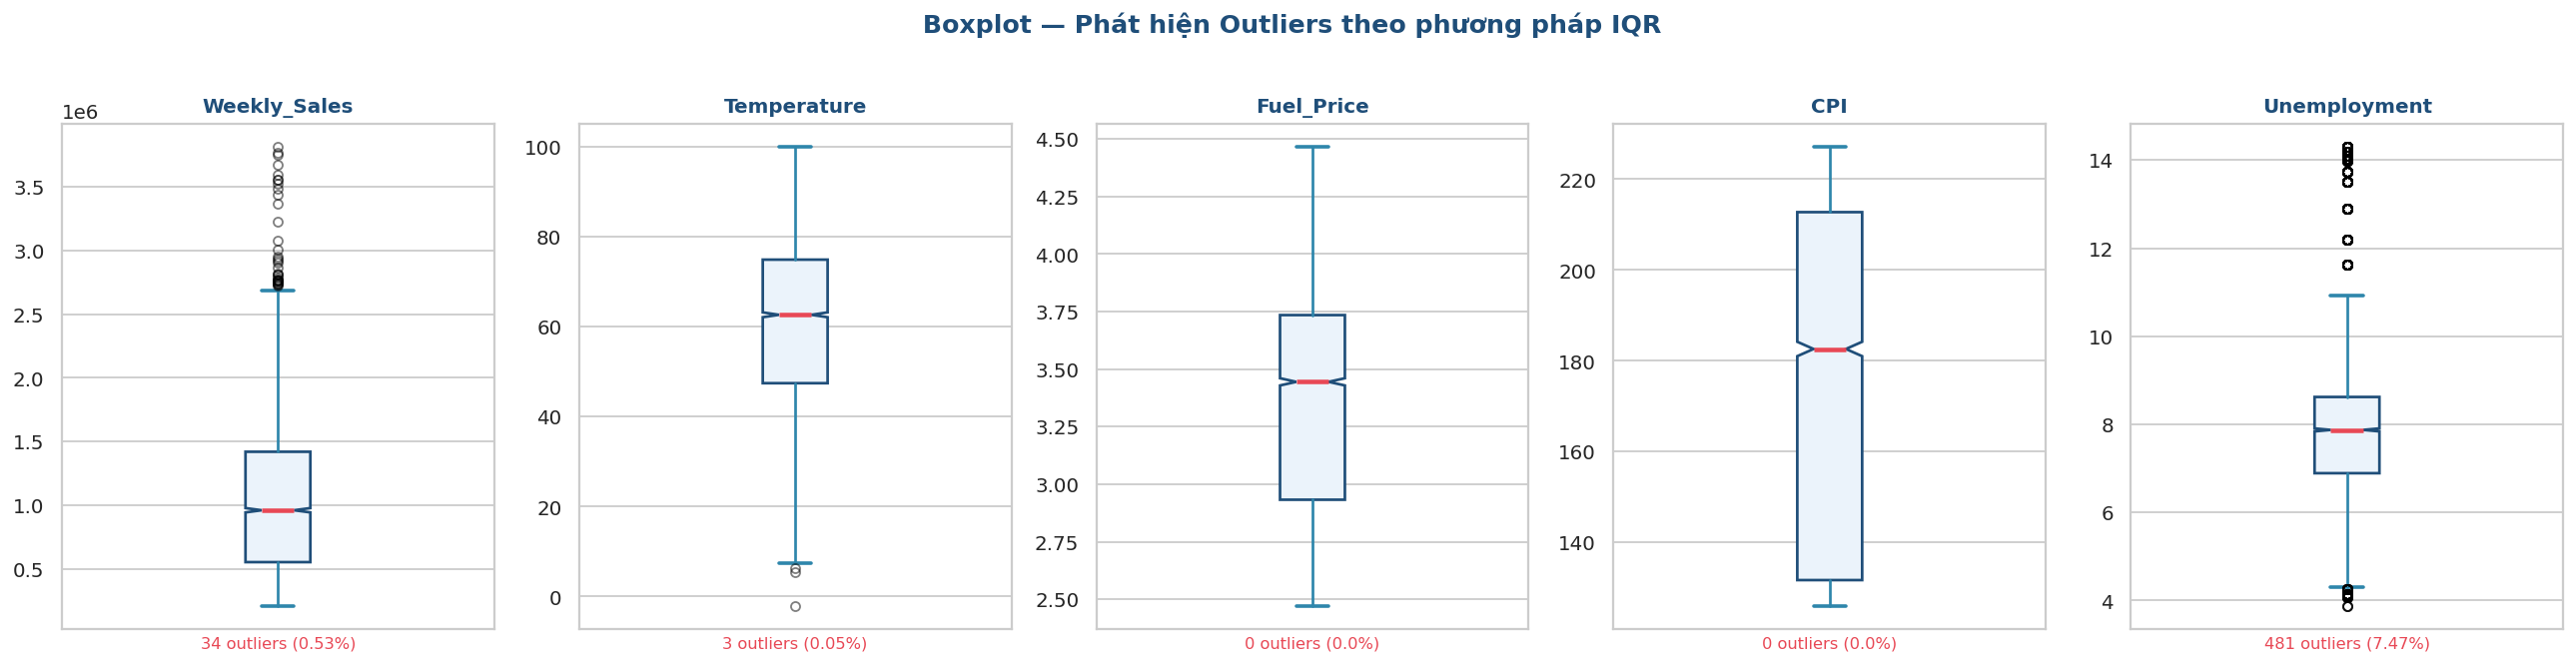

 Lưu: outliers_boxplot.png


In [ ]:
# 2.5 Outlier Detection — IQR Method
print('[2.5] Phát hiện Outliers (IQR Method):')
numeric_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']
report = []
for col in numeric_cols:
    Q1=df[col].quantile(0.25); Q3=df[col].quantile(0.75); IQR=Q3-Q1
    lo=Q1-1.5*IQR; hi=Q3+1.5*IQR
    n=((df[col]<lo)|(df[col]>hi)).sum()
    report.append({'Column':col,'Lower':round(lo,2),'Upper':round(hi,2),'Outliers':n,'%':round(n/len(df)*100,2)})
print(pd.DataFrame(report).set_index('Column'))

fig, axes = plt.subplots(1,5,figsize=(20,5))
for i,col in enumerate(numeric_cols):
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True, notch=True,
        boxprops=dict(facecolor=COLORS['light'],color=COLORS['primary'],linewidth=1.5),
        medianprops=dict(color=COLORS['accent'],linewidth=2.5),
        whiskerprops=dict(color=COLORS['secondary'],linewidth=1.5),
        capprops=dict(color=COLORS['secondary'],linewidth=2),
        flierprops=dict(marker='o',color=COLORS['accent'],alpha=0.5,markersize=5))
    axes[i].set_title(col, fontsize=11, fontweight='bold', color=COLORS['primary'])
    axes[i].set_xticks([])
    n_out = report[i]['Outliers']
    axes[i].set_xlabel(f'{n_out} outliers ({report[i]["%"]}%)', fontsize=9, color=COLORS['accent'])
fig.suptitle(' Boxplot — Phát hiện Outliers theo phương pháp IQR', fontsize=14, fontweight='bold', color=COLORS['primary'], y=1.02)
plt.tight_layout()
plt.savefig('outliers_boxplot.png',dpi=150,bbox_inches='tight')
plt.show()
print(' Lưu: outliers_boxplot.png')

The boxplots illustrate the distribution of five variables in the Walmart dataset, namely Weekly Sales, Temperature, Fuel Price, CPI and Unemployment, with outliers detected using the IQR method.

Overall, most variables display relatively stable distributions with limited extreme values. However, Weekly Sales and Unemployment stand out for showing a noticeable number of outliers, indicating greater variability compared with the other indicators.

In detail, Unemployment records by far the highest number of outliers, with 481 observations, accounting for approximately 7.5% of the dataset. These extreme values are mainly located above the upper whisker, suggesting occasional spikes in unemployment rates across different regions or periods. In contrast, Weekly Sales also exhibits outliers, though to a much lesser extent, with only 34 points, representing around 0.5% of the data. Most of these lie on the upper end of the scale, reflecting unusually high sales figures.

By comparison, Fuel Price and CPI show no detected outliers, indicating that both variables remain consistently within a narrow range throughout the observed period. Temperature presents only three outliers, accounting for a negligible proportion of the data, which implies generally stable weather conditions with very few abnormal observations.

Các biểu đồ boxplot minh họa sự phân bố của năm biến trong bộ dữ liệu Walmart, bao gồm Weekly Sales, Temperature, Fuel Price, CPI và Unemployment, với các giá trị ngoại lai được xác định bằng phương pháp IQR.

Nhìn chung, phần lớn các biến có phân phối khá ổn định và chỉ xuất hiện rất ít giá trị cực đoan. Tuy nhiên, Weekly Sales và Unemployment nổi bật do có số lượng outliers đáng kể hơn so với các biến còn lại, cho thấy mức độ biến thiên cao hơn.

Cụ thể, Unemployment ghi nhận số lượng outliers lớn nhất, với 481 quan sát, chiếm khoảng 7,5% tổng dữ liệu. Các giá trị bất thường này chủ yếu nằm phía trên whisker trên, cho thấy một số thời điểm hoặc khu vực có tỷ lệ thất nghiệp tăng đột biến. Ngược lại, Weekly Sales cũng xuất hiện outliers nhưng ở mức độ thấp hơn nhiều, chỉ gồm 34 điểm, tương đương khoảng 0,5% dữ liệu. Phần lớn các giá trị này tập trung ở phía trên, phản ánh những giai đoạn doanh thu đặc biệt cao.

Trong khi đó, Fuel Price và CPI không ghi nhận bất kỳ outlier nào, cho thấy hai biến này duy trì trong biên độ tương đối hẹp trong suốt giai đoạn quan sát. Temperature chỉ có ba outliers, chiếm tỷ lệ không đáng kể, hàm ý rằng điều kiện nhiệt độ nhìn chung ổn định và hiếm khi xuất hiện các giá trị bất thường.

---
##  PHASE 3 — Data Transformation

In [ ]:
# PHASE 3: DATA TRANSFORMATION & FEATURE ENGINEERING

print('   PHASE 3 — TRANSFORMATION & FEATURE ENGINEERING')


df_t = df.copy()

# 3.1 Thời gian
df_t['Year']    = df_t['Date'].dt.year
df_t['Month']   = df_t['Date'].dt.month
df_t['Week']    = df_t['Date'].dt.isocalendar().week.astype(int)
df_t['Quarter'] = df_t['Date'].dt.quarter
df_t['Season']  = df_t['Month'].map(lambda m: 'Winter' if m in [12,1,2] else 'Spring' if m in [3,4,5] else 'Summer' if m in [6,7,8] else 'Fall')
print(' Thêm: Year, Month, Week, Quarter, Season')

# 3.2 Store Tier
store_avg = df_t.groupby('Store')['Weekly_Sales'].mean()
q33,q66 = store_avg.quantile(0.33), store_avg.quantile(0.66)
tier_map = store_avg.apply(lambda x: 'High' if x>=q66 else ('Low' if x<q33 else 'Medium'))
df_t = df_t.merge(tier_map.rename('Store_Tier'), on='Store', how='left')
print(' Thêm: Store_Tier (High / Medium / Low)')

# 3.3 Rolling MA4
df_t = df_t.sort_values(['Store','Date'])
df_t['Sales_MA4'] = df_t.groupby('Store')['Weekly_Sales'].transform(lambda x: x.rolling(4,min_periods=1).mean()).round(2)
print(' Thêm: Sales_MA4 (rolling mean 4 tuần)')

# 3.4 WoW Growth
df_t['Sales_WoW'] = df_t.groupby('Store')['Weekly_Sales'].pct_change()*100
df_t['Sales_WoW'] = df_t['Sales_WoW'].round(2)
print(' Thêm: Sales_WoW (Week-over-Week growth %)')

# 3.5 Lag features
df_t['Sales_Lag1'] = df_t.groupby('Store')['Weekly_Sales'].shift(1)
df_t['Sales_Lag4'] = df_t.groupby('Store')['Weekly_Sales'].shift(4)
print(' Thêm: Sales_Lag1, Sales_Lag4')

# 3.6 Normalization
for col in ['Temperature','Fuel_Price','CPI','Unemployment']:
    mn,mx = df_t[col].min(), df_t[col].max()
    df_t[f'{col}_norm'] = ((df_t[col]-mn)/(mx-mn)).round(4)
print(' Thêm: *_norm (Min-Max scaling)')

print(f'\n Cột sau transform: {df_t.shape[1]} (ban đầu: {df_raw.shape[1]})')
df_t[['Store','Date','Weekly_Sales','Year','Month','Season','Store_Tier','Sales_MA4','Sales_WoW']].head(8)

   PHASE 3 — TRANSFORMATION & FEATURE ENGINEERING
 Thêm: Year, Month, Week, Quarter, Season
 Thêm: Store_Tier (High / Medium / Low)
 Thêm: Sales_MA4 (rolling mean 4 tuần)
 Thêm: Sales_WoW (Week-over-Week growth %)
 Thêm: Sales_Lag1, Sales_Lag4
 Thêm: *_norm (Min-Max scaling)

 Cột sau transform: 22 (ban đầu: 8)


,Store,Date,Weekly_Sales,Year,Month,Season,Store_Tier,Sales_MA4,Sales_WoW
0,1,2010-02-05,1643690.90,2010,2,Winter,High,1643690.90,NaN
1,1,2010-02-12,1641957.44,2010,2,Winter,High,1642824.17,-0.11
2,1,2010-02-19,1611968.17,2010,2,Winter,High,1632538.84,-1.83
3,1,2010-02-26,1409727.59,2010,2,Winter,High,1576836.02,-12.55
4,1,2010-03-05,1554806.68,2010,3,Spring,High,1554614.97,10.29
5,1,2010-03-12,1439541.59,2010,3,Spring,High,1504011.01,-7.41
6,1,2010-03-19,1472515.79,2010,3,Spring,High,1469147.91,2.29
7,1,2010-03-26,1404429.92,2010,3,Spring,High,1467823.50,-4.62


Mô tả tổng quan:

Phase 3 thực hiện việc biến đổi và mở rộng tập dữ liệu thông qua kỹ thuật Feature Engineering, tạo ra 9 features mới từ 8 cột ban đầu. Nhìn chung, đây là giai đoạn quan trọng nhất trong pipeline vì chất lượng của các features được tạo ra sẽ trực tiếp quyết định hiệu quả phân tích ở Phase 5 và độ chính xác của mô hình ML ở Phase 6.

Phân tích chi tiết:

Nhóm features thời gian gồm Year, Month, Week, Quarter, Season được trích xuất từ cột Date bằng các thuộc tính .dt của Pandas. Đây là bước cần thiết vì cột Date ở dạng nguyên bản không thể dùng trực tiếp trong phân tích thống kê hay mô hình ML — việc phân rã thành các đơn vị nhỏ hơn cho phép phát hiện tính thời vụ theo nhiều chiều cùng lúc.

Store_Tier được xây dựng bằng cách tính doanh thu trung bình của từng store rồi phân vị thành 3 nhóm — một kỹ thuật phân loại có giám sát dựa trên ngưỡng thống kê. Kết quả cho ra 15 High – 15 Medium – 15 Low, phân bố đều, cho thấy ngưỡng phân vị Q33/Q66 là lựa chọn hợp lý.

Sales_MA4 (rolling mean 4 tuần) được tính theo từng Store riêng biệt bằng groupby().transform() thay vì rolling thẳng trên toàn DataFrame — đây là điểm kỹ thuật quan trọng, tránh tình trạng dữ liệu của Store này ảnh hưởng sang Store khác khi sắp xếp theo ngày. MA4 giúp làm mịn nhiễu ngắn hạn, làm nổi bật xu hướng trung hạn của từng cửa hàng.

Sales_WoW_Growth đo lường tốc độ thay đổi tuần-qua-tuần bằng pct_change(), cung cấp góc nhìn về tốc độ thay đổi thay vì chỉ giá trị tuyệt đối — feature này đặc biệt hữu ích để phát hiện các tuần tăng đột biến hoặc sụt giảm bất thường.

Sales_Lag1 và Sales_Lag4 là hai lag features tạo ra bằng shift(), cho phép mô hình ML "nhìn về quá khứ" để dự báo tương lai — đây là kỹ thuật chuẩn trong bài toán dự báo chuỗi thời gian (time series forecasting).

Cuối cùng, Min-Max Normalization chuẩn hoá 4 biến liên tục (Temperature, Fuel_Price, CPI, Unemployment) về khoảng [0, 1], đảm bảo các biến có đơn vị và biên độ khác nhau không gây ra sự thiên lệch trong mô hình ML.

Tổng kết: Sau Phase 3, DataFrame mở rộng từ 8 lên 17 cột, cung cấp đầy đủ nguyên liệu cho cả phân tích thống kê lẫn mô hình dự báo ở các phase tiếp theo.

---
##  PHASE 4 — Data Storage (SQLite)

In [ ]:
# PHASE 4: DATA STORAGE — SQLite

DB = 'walmart_pipeline.db'
conn = sqlite3.connect(DB)
cur  = conn.cursor()

# Lưu fact_sales
save_df = df_t.copy()
save_df['Date'] = save_df['Date'].astype(str)
save_df.columns = [c.lower().replace(' ','_') for c in save_df.columns]
save_df.to_sql('fact_sales', conn, if_exists='replace', index=False)

# Lưu dim_store
store_dim = df_t.groupby(['Store','Store_Tier']).agg(
    avg_sales=('Weekly_Sales','mean'),
    total_sales=('Weekly_Sales','sum'),
    num_weeks=('Weekly_Sales','count')
).reset_index().round(2)
store_dim.to_sql('dim_store', conn, if_exists='replace', index=False)

conn.commit()
n_rows = cur.execute('SELECT COUNT(*) FROM fact_sales').fetchone()[0]
print(' Database:', DB)
print(f'   fact_sales : {n_rows:,} rows')
print(f'   dim_store  : {store_dim.shape[0]} stores')

# Test SQL queries
print('\n--- Top 5 stores theo doanh thu ---')
print(pd.read_sql('SELECT store, store_tier, ROUND(SUM(weekly_sales)/1e6,2) AS total_M FROM fact_sales GROUP BY store ORDER BY total_M DESC LIMIT 5', conn))

 Database: walmart_pipeline.db
   fact_sales : 6,435 rows
   dim_store  : 45 stores

--- Top 5 stores theo doanh thu ---
   store store_tier  total_M
0     20       High   301.40
1      4       High   299.54
2     14       High   289.00
3     13       High   286.52
4      2       High   275.38


---
##  PHASE 5 — Analysis & Visualization

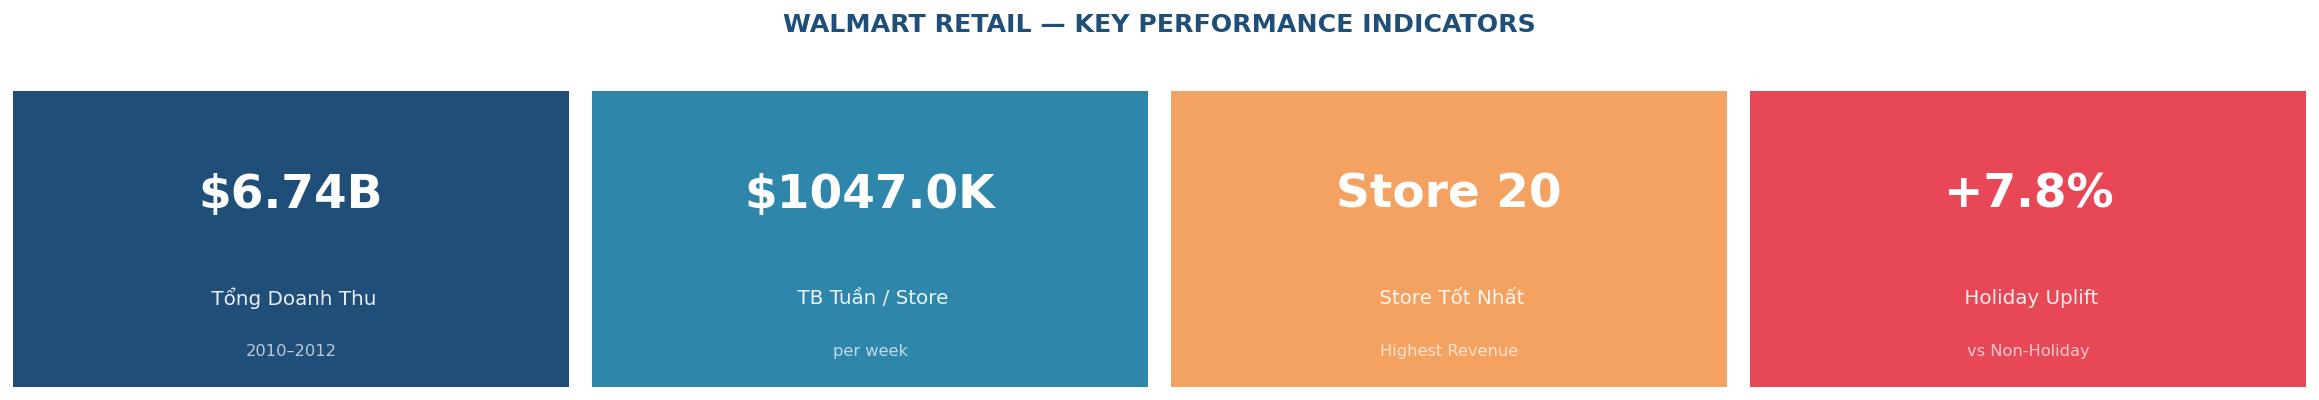

 Lưu: kpi_dashboard.png


In [ ]:
# VIZ 1: TỔNG QUAN DASHBOARD (4 KPIs)

total_sales = df_t['Weekly_Sales'].sum()
avg_weekly  = df_t['Weekly_Sales'].mean()
best_store  = df_t.groupby('Store')['Weekly_Sales'].sum().idxmax()
holiday_up  = (df_t[df_t['Holiday_Flag']==1]['Weekly_Sales'].mean() / df_t[df_t['Holiday_Flag']==0]['Weekly_Sales'].mean()-1)*100

fig, axes = plt.subplots(1,4,figsize=(18,3))
kpis = [
    (' Tổng Doanh Thu', f'${total_sales/1e9:.2f}B', '2010–2012', COLORS['primary']),
    (' TB Tuần / Store', f'${avg_weekly/1e3:.1f}K', 'per week', COLORS['secondary']),
    (' Store Tốt Nhất', f'Store {best_store}', 'Highest Revenue', COLORS['orange']),
    (' Holiday Uplift', f'+{holiday_up:.1f}%', 'vs Non-Holiday', COLORS['accent']),
]
for ax,(title,val,sub,color) in zip(axes,kpis):
    ax.set_facecolor(color)
    ax.text(0.5,0.65,val,transform=ax.transAxes,ha='center',va='center',
            fontsize=26,fontweight='bold',color='white')
    ax.text(0.5,0.30,title,transform=ax.transAxes,ha='center',va='center',
            fontsize=11,color='white',alpha=0.9)
    ax.text(0.5,0.12,sub,transform=ax.transAxes,ha='center',va='center',
            fontsize=9,color='white',alpha=0.7)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
fig.suptitle('WALMART RETAIL — KEY PERFORMANCE INDICATORS', fontsize=14, fontweight='bold', y=1.02, color=COLORS['primary'])
plt.tight_layout()
plt.savefig('kpi_dashboard.png',dpi=150,bbox_inches='tight')
plt.show()
print(' Lưu: kpi_dashboard.png')

Dashboard KPI cung cấp cái nhìn tổng quan về hiệu quả hoạt động bán lẻ của Walmart trong giai đoạn 2010–2012, tập trung vào bốn chỉ số chính phản ánh quy mô doanh thu, mức độ ổn định theo thời gian, hiệu suất cửa hàng và tác động của yếu tố mùa vụ.

Tổng doanh thu đạt khoảng 6,74 tỷ USD, cho thấy quy mô hoạt động lớn và doanh số tích lũy đáng kể trong toàn bộ giai đoạn phân tích. Con số này đặt nền tảng cho các phân tích sâu hơn về xu hướng theo thời gian và sự khác biệt giữa các cửa hàng.

Doanh thu trung bình hàng tuần trên mỗi cửa hàng vào khoảng 1,047 triệu USD, phản ánh mức doanh số ổn định theo tuần, đồng thời cho thấy bán lẻ tại Walmart có tính chu kỳ rõ ràng nhưng vẫn duy trì được quy mô cao trên toàn hệ thống. Chỉ số này đặc biệt hữu ích để so sánh hiệu suất giữa các cửa hàng và đánh giá biến động doanh thu trong các giai đoạn đặc biệt.

Về hiệu suất cửa hàng, Store 20 được xác định là cửa hàng có doanh thu cao nhất trong toàn bộ tập dữ liệu. Điều này cho thấy sự tồn tại của chênh lệch đáng kể về hiệu quả kinh doanh giữa các cửa hàng, có thể liên quan đến quy mô, vị trí địa lý hoặc đặc điểm nhu cầu địa phương.

Cuối cùng, chỉ số Holiday Uplift cho thấy doanh thu trung bình trong các tuần có kỳ nghỉ lễ cao hơn khoảng 7,8% so với các tuần thông thường. Kết quả này khẳng định tác động tích cực của yếu tố mùa vụ đối với hành vi tiêu dùng, đồng thời nhấn mạnh tầm quan trọng của việc lập kế hoạch hàng tồn kho và marketing trong các dịp lễ.

Nhìn chung, dashboard KPI đóng vai trò như một điểm khởi đầu quan trọng, giúp định hướng cho các phân tích trực quan tiếp theo liên quan đến xu hướng theo thời gian, so sánh giữa các cửa hàng và ảnh hưởng của các yếu tố kinh tế – xã hội đến doanh thu.

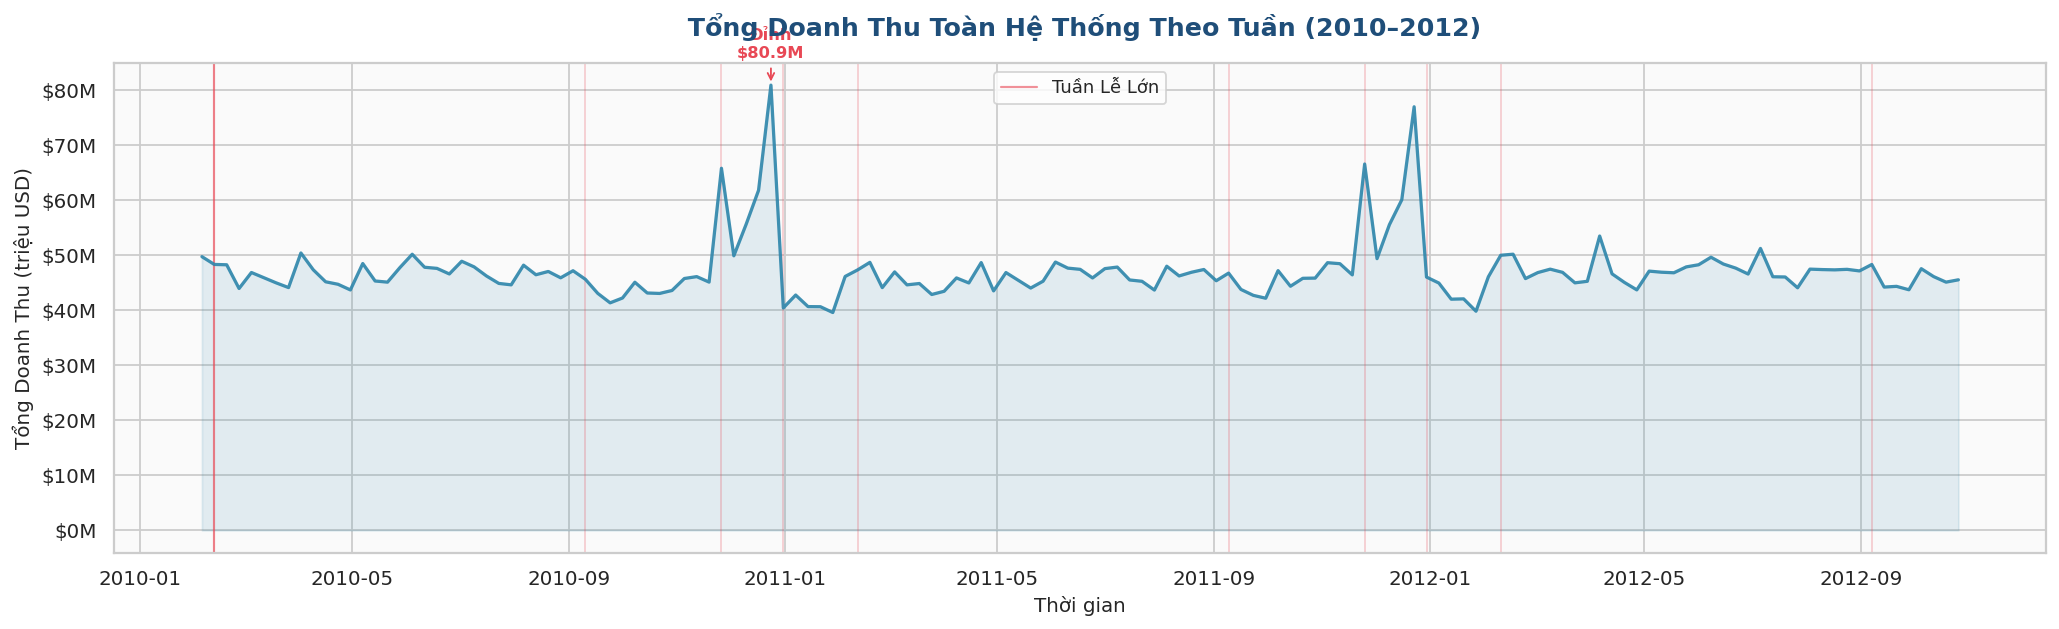

 Lưu: trend_weekly.png


In [ ]:
# VIZ 2: XU HƯỚNG DOANH THU THEO TUẦN

weekly = df_t.groupby('Date')['Weekly_Sales'].sum().reset_index()
holiday_dates = df_t[df_t['Holiday_Flag']==1]['Date'].unique()

fig, ax = plt.subplots(figsize=(16,5))
ax.plot(weekly['Date'], weekly['Weekly_Sales']/1e6, color=COLORS['secondary'], lw=1.8, alpha=0.9, zorder=3)
ax.fill_between(weekly['Date'], weekly['Weekly_Sales']/1e6, alpha=0.12, color=COLORS['secondary'])
for hd in holiday_dates:
    ax.axvline(x=hd,color=COLORS['accent'],alpha=0.25,lw=1)
ax.axvline(x=holiday_dates[0],color=COLORS['accent'],alpha=0.6,lw=1.2,label='Tuần Lễ Lớn')

# Đánh dấu đỉnh
peak_idx = weekly['Weekly_Sales'].idxmax()
peak_date = weekly.loc[peak_idx,'Date']
peak_val  = weekly.loc[peak_idx,'Weekly_Sales']/1e6
ax.annotate(f'Đỉnh\n${peak_val:.1f}M', xy=(peak_date,peak_val),
    xytext=(peak_date,peak_val+5), ha='center',
    arrowprops=dict(arrowstyle='->', color=COLORS['accent']),
    fontsize=9, color=COLORS['accent'], fontweight='bold')

ax.set_title(' Tổng Doanh Thu Toàn Hệ Thống Theo Tuần (2010–2012)', fontsize=14, fontweight='bold', color=COLORS['primary'], pad=15)
ax.set_xlabel('Thời gian', fontsize=11)
ax.set_ylabel('Tổng Doanh Thu (triệu USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax.legend(fontsize=10)
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('trend_weekly.png',dpi=150,bbox_inches='tight')
plt.show()
print(' Lưu: trend_weekly.png')

Biểu đồ đường thể hiện xu hướng tổng doanh thu toàn hệ thống Walmart theo từng tuần trong giai đoạn 2010–2012, giúp làm rõ sự biến động theo thời gian cũng như tác động của các tuần lễ lớn đến hiệu suất bán hàng.

Nhìn chung, doanh thu hàng tuần duy trì ở mức tương đối ổn định, dao động quanh khoảng 45–50 triệu USD, cho thấy hoạt động kinh doanh của Walmart có tính bền vững cao trong dài hạn. Tuy nhiên, bên cạnh xu hướng ổn định này, biểu đồ cũng cho thấy các đợt tăng vọt rõ rệt xuất hiện theo chu kỳ hàng năm.

Các đường thẳng đứng đánh dấu tuần có kỳ nghỉ lễ cho thấy mối liên hệ chặt chẽ giữa mùa vụ và doanh thu. Hầu hết các đỉnh doanh thu đều trùng với các dịp lễ lớn, đặc biệt là vào cuối năm. Đỉnh cao nhất của toàn bộ giai đoạn được ghi nhận rơi vào thời điểm cuối năm 2010, với doanh thu xấp xỉ 80,9 triệu USD, cao hơn đáng kể so với mức trung bình các tuần thông thường.

Sau các giai đoạn cao điểm này, doanh thu thường nhanh chóng quay trở lại mức nền ổn định, phản ánh tính chất ngắn hạn của hiệu ứng mùa vụ. Điều này cho thấy mặc dù các dịp lễ có tác động mạnh đến doanh số, nhưng chúng không làm thay đổi xu hướng dài hạn của doanh thu toàn hệ thống.

Tổng thể, biểu đồ xu hướng theo tuần nhấn mạnh hai đặc điểm chính: tính ổn định của doanh thu cơ sở và tác động rõ ràng nhưng mang tính thời điểm của các kỳ nghỉ lễ. Kết quả này cung cấp cơ sở quan trọng cho những phân tích tiếp theo liên quan đến dự báo nhu cầu, quản lý tồn kho và chiến lược kinh doanh theo mùa.

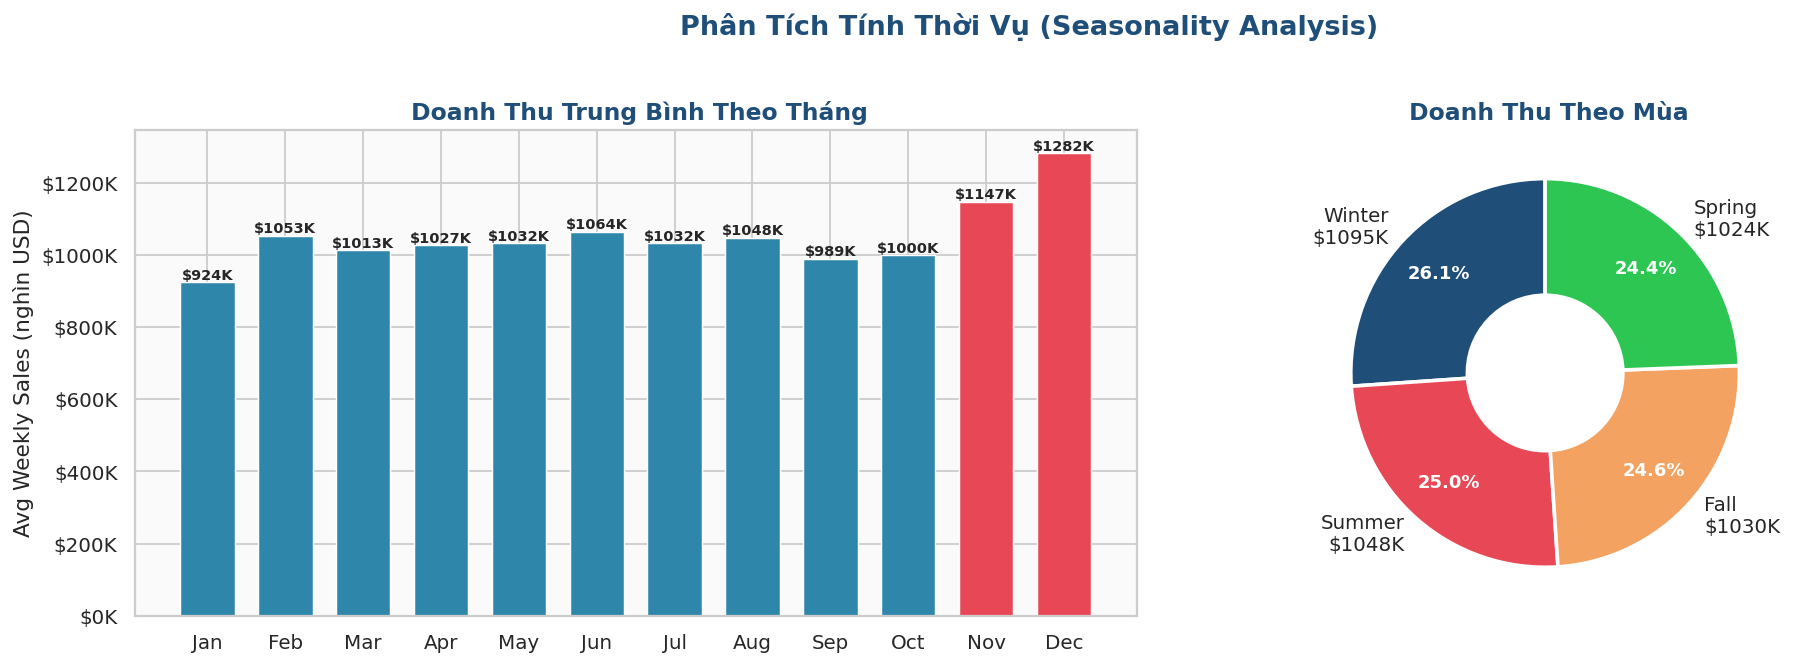

 Lưu: seasonality.png


In [ ]:

# VIZ 3: SEASONALITY — THÁNG & MÙA

month_avg = df_t.groupby('Month')['Weekly_Sales'].mean()
season_avg = df_t.groupby('Season')['Weekly_Sales'].mean().sort_values(ascending=False)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,5))

# Bar chart theo tháng
cols_m = [COLORS['accent'] if m in [11,12] else COLORS['secondary'] for m in range(1,13)]
bars = ax1.bar(month_names, month_avg.values/1e3, color=cols_m, edgecolor='white', lw=0.8, width=0.7)
ax1.set_title(' Doanh Thu Trung Bình Theo Tháng', fontsize=13, fontweight='bold', color=COLORS['primary'])
ax1.set_ylabel('Avg Weekly Sales (nghìn USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
for bar,val in zip(bars,month_avg.values/1e3):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'${val:.0f}K',
             ha='center',va='bottom',fontsize=8,fontweight='bold')
ax1.set_facecolor('#FAFAFA')
ax1.tick_params(axis='x',rotation=0)

# Donut chart theo mùa
season_colors = {'Winter':COLORS['primary'],'Fall':COLORS['orange'],'Summer':COLORS['accent'],'Spring':COLORS['green']}
wedge_colors = [season_colors[s] for s in season_avg.index]
wedges,texts,autotexts = ax2.pie(
    season_avg.values, labels=[f'{s}\n${v/1e3:.0f}K' for s,v in zip(season_avg.index,season_avg.values)],
    colors=wedge_colors, autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white', lw=2),
    pctdistance=0.75)
for at in autotexts: at.set_fontsize(10); at.set_color('white'); at.set_fontweight('bold')
ax2.set_title(' Doanh Thu Theo Mùa', fontsize=13, fontweight='bold', color=COLORS['primary'])

fig.suptitle('Phân Tích Tính Thời Vụ (Seasonality Analysis)', fontsize=15, fontweight='bold', color=COLORS['primary'], y=1.02)
plt.tight_layout()
plt.savefig('seasonality.png',dpi=150,bbox_inches='tight')
plt.show()
print(' Lưu: seasonality.png')

Biểu đồ cho thấy phân tích doanh thu trung bình hàng tuần theo tháng và theo mùa trong một năm. Nhìn chung, doanh thu trong năm tương đối ổn định nhưng tăng đáng kể vào cuối năm, đặc biệt là trong mùa đông.

Xét theo tháng, doanh thu thấp nhất được ghi nhận vào tháng 1 với $924K. Sau đó, doanh thu tăng dần và duy trì ở mức tương đối ổn định từ tháng 2 đến tháng 8, dao động trong khoảng $1013K đến $1064K. Tháng 9 và tháng 10 chứng kiến sự giảm nhẹ xuống còn $989K và $1000K. Tuy nhiên, vào cuối năm, doanh thu tăng đột biến với $1147K vào tháng 11 và đạt mức cao nhất trong năm là $1282K vào tháng 12.

Xét theo mùa, mùa đông đạt doanh thu trung bình cao nhất là $1095K, chiếm 26,1% tổng doanh thu theo mùa. Mùa hè cũng có doanh thu đáng kể với $1048K (25%). Trong khi đó, mùa thu và mùa xuân có doanh thu thấp hơn, lần lượt là $1030K (24,6%) và $1024K (24,4%).

Nhìn chung, dữ liệu cho thấy xu hướng tăng mạnh vào cuối năm, có thể liên quan đến các dịp lễ hội hoặc mùa mua sắm. Phần lớn các tháng còn lại duy trì doanh thu ổn định, phản ánh sự cân bằng trong hoạt động kinh doanh quanh năm.

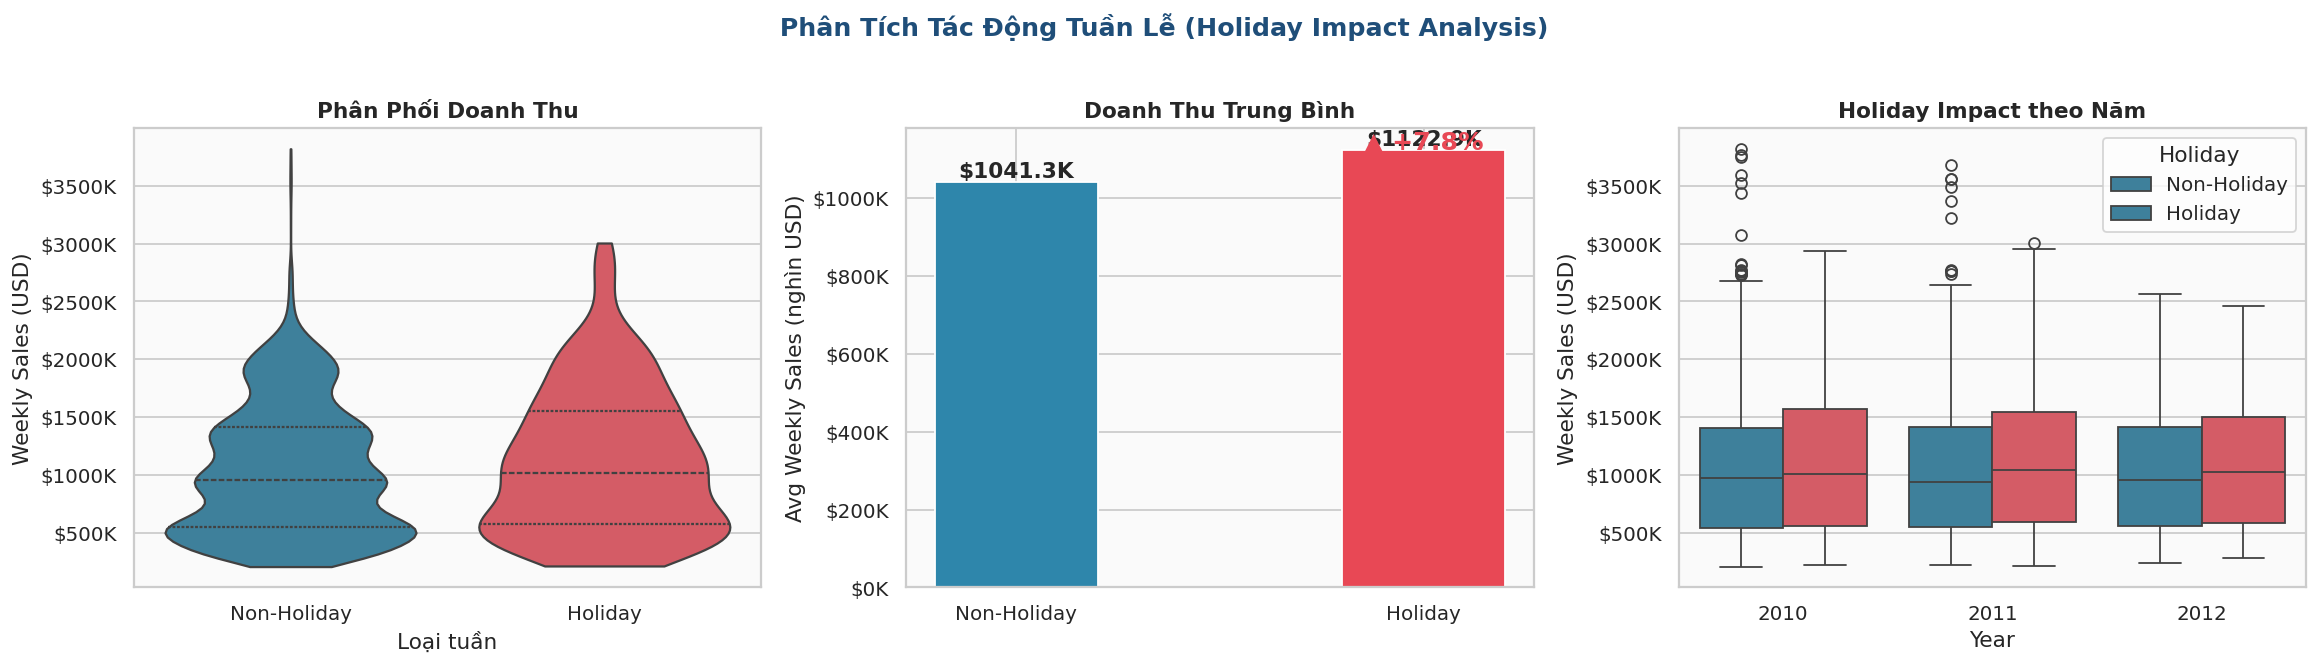


Holiday Uplift: +7.8% so với tuần thường
 Lưu: holiday_impact.png


In [ ]:

# VIZ 4: HOLIDAY vs NON-HOLIDAY

hol  = df_t[df_t['Holiday_Flag']==1]['Weekly_Sales']
nhol = df_t[df_t['Holiday_Flag']==0]['Weekly_Sales']
uplift = (hol.mean()-nhol.mean())/nhol.mean()*100

fig, axes = plt.subplots(1,3,figsize=(18,5))

# Violin plot
plot_data = df_t[['Weekly_Sales','Holiday_Flag']].copy()
plot_data['Loại tuần'] = plot_data['Holiday_Flag'].map({0:'Non-Holiday',1:'Holiday'})
sns.violinplot(data=plot_data, x='Loại tuần', y='Weekly_Sales', ax=axes[0],
    palette={'Non-Holiday':COLORS['secondary'],'Holiday':COLORS['accent']},
    inner='quartile', cut=0)
axes[0].set_title('Phân Phối Doanh Thu', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Weekly Sales (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].set_facecolor('#FAFAFA')

# Bar chart so sánh
labels = ['Non-Holiday','Holiday']
vals   = [nhol.mean(), hol.mean()]
bars   = axes[1].bar(labels, [v/1e3 for v in vals], color=[COLORS['secondary'],COLORS['accent']], width=0.4)
axes[1].set_title('Doanh Thu Trung Bình', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Weekly Sales (nghìn USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
for bar,val in zip(bars,vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'${val/1e3:.1f}K', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].annotate(f'▲ +{uplift:.1f}%', xy=(1, hol.mean()/1e3+1),
    fontsize=14, color=COLORS['accent'], fontweight='bold', ha='center')
axes[1].set_facecolor('#FAFAFA')

# Box plot theo năm + holiday
sns.boxplot(data=df_t, x='Year', y='Weekly_Sales', hue='Holiday_Flag', ax=axes[2],
    palette={0:COLORS['secondary'],1:COLORS['accent']})
axes[2].set_title('Holiday Impact theo Năm', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Weekly Sales (USD)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[2].legend(title='Holiday', labels=['Non-Holiday','Holiday'])
axes[2].set_facecolor('#FAFAFA')

fig.suptitle(' Phân Tích Tác Động Tuần Lễ (Holiday Impact Analysis)', fontsize=14, fontweight='bold', color=COLORS['primary'], y=1.02)
plt.tight_layout()
plt.savefig('holiday_impact.png',dpi=150,bbox_inches='tight')
plt.show()
print(f'\nHoliday Uplift: +{uplift:.1f}% so với tuần thường')
print(' Lưu: holiday_impact.png')

Biểu đồ thể hiện tác động của các tuần lễ (Holiday) đối với doanh thu trung bình hàng tuần trong hệ thống. Nhìn chung, doanh thu trung bình trong các tuần lễ cao hơn so với các tuần thường (Non-Holiday), phản ánh hiệu ứng tích cực của các dịp lễ.

Xét theo phân phối doanh thu, biểu đồ Violin cho thấy tuần lễ có giá trị trung bình cao hơn và độ biến động lớn hơn, với một số tuần lễ đạt doanh thu cực kỳ cao. Tuần thường có phân phối hẹp hơn, doanh thu trung bình thấp hơn và ổn định hơn.

Biểu đồ thanh so sánh doanh thu trung bình giữa hai loại tuần cho thấy: doanh thu trung bình của tuần lễ là $1,122.9K, cao hơn $1,041.3K của tuần thường, tương ứng với mức tăng 7.8%. Điều này nhấn mạnh rằng các dịp lễ là yếu tố thúc đẩy doanh thu.

Biểu đồ Box Plot theo năm minh họa xu hướng tương tự: trong các năm 2010–2012, các tuần lễ luôn có doanh thu trung bình cao hơn so với tuần thường. Mặc dù vẫn tồn tại một số giá trị ngoại lai, sự khác biệt giữa hai loại tuần vẫn duy trì đều qua các năm.

Tóm lại, dữ liệu cho thấy các tuần lễ đóng vai trò quan trọng trong việc thúc đẩy doanh thu trung bình, và doanh nghiệp có thể tận dụng dịp này để tối ưu hóa doanh thu hàng tuần.

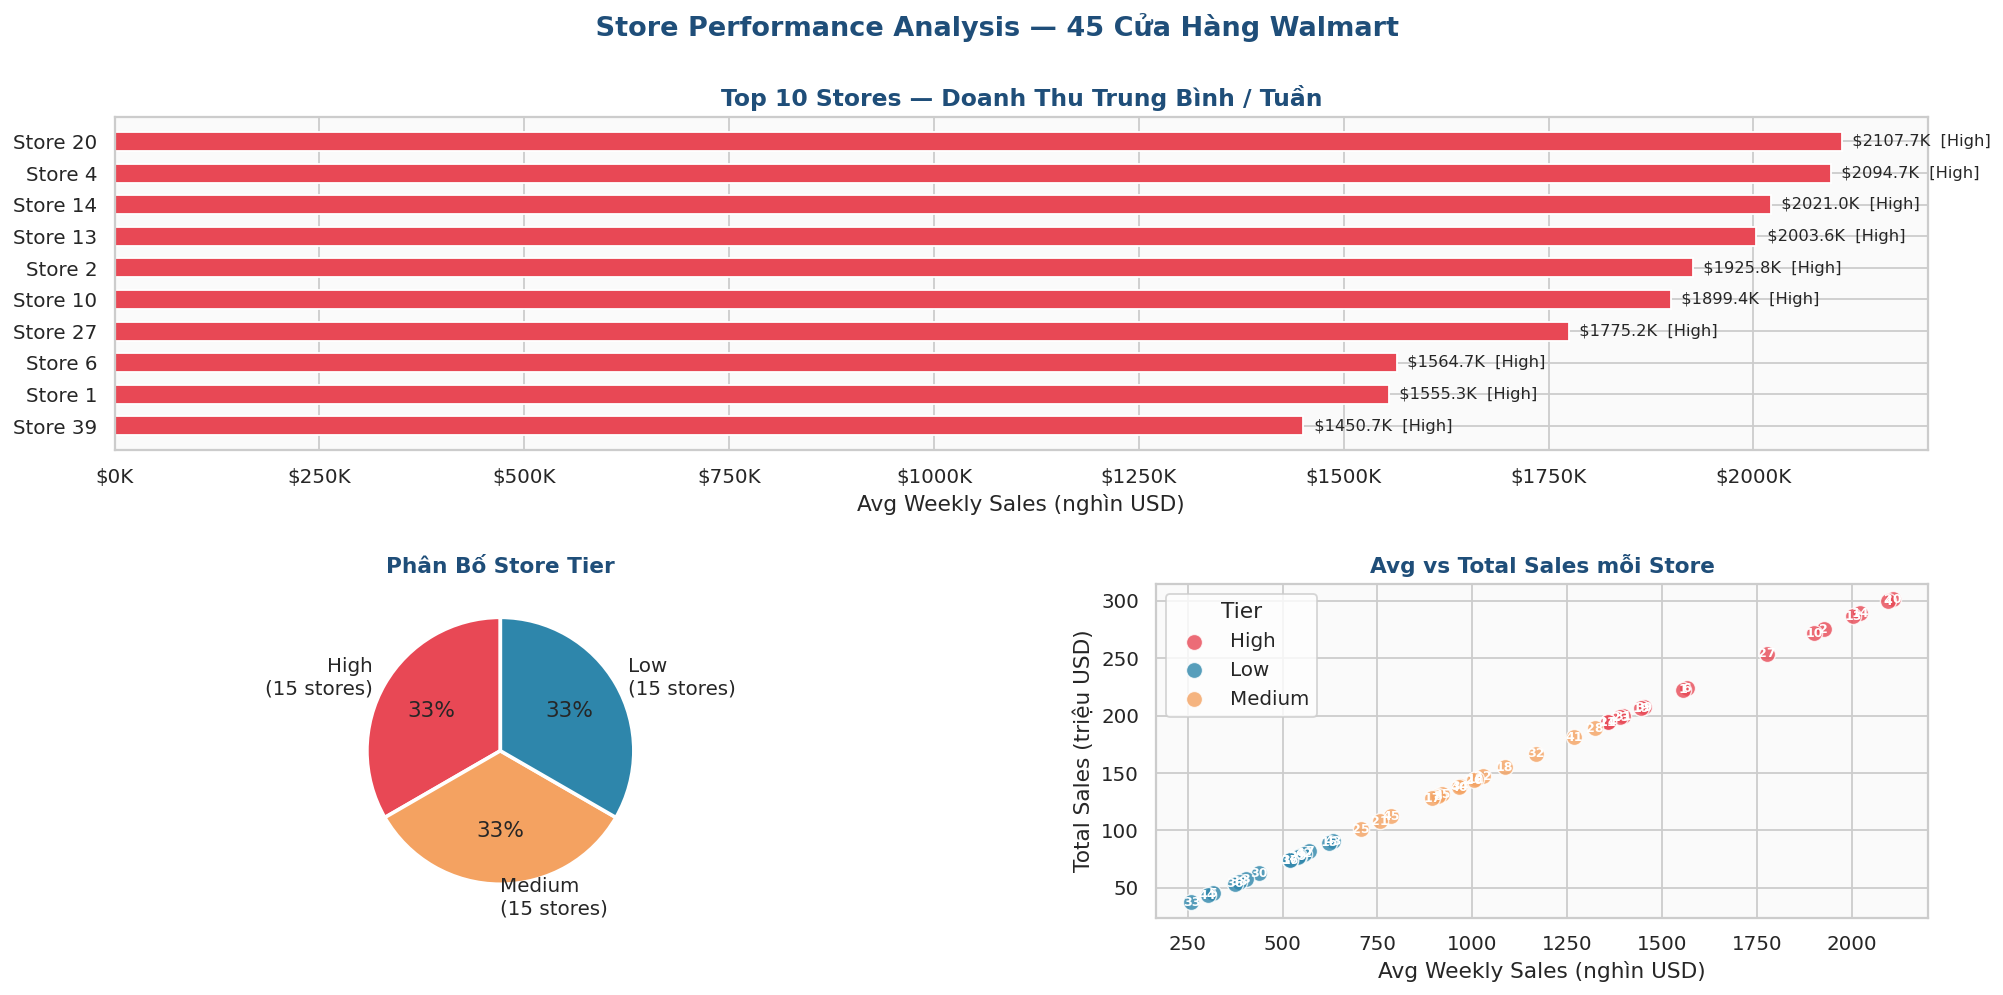

 Lưu: store_performance.png


In [ ]:
# VIZ 5: STORE PERFORMANCE

store_perf = df_t.groupby(['Store','Store_Tier']).agg(
    Total=('Weekly_Sales','sum'), Avg=('Weekly_Sales','mean'), Weeks=('Weekly_Sales','count')
).reset_index().sort_values('Avg',ascending=False)

fig = plt.figure(figsize=(18,8))
gs  = gridspec.GridSpec(2,2,figure=fig,hspace=0.4,wspace=0.35)

# Top 10
ax1 = fig.add_subplot(gs[0,:])
top10 = store_perf.head(10)
tier_c = {'High':COLORS['accent'],'Medium':COLORS['orange'],'Low':COLORS['secondary']}
cols = [tier_c[t] for t in top10['Store_Tier']]
bars = ax1.barh([f'Store {s}' for s in top10['Store']], top10['Avg']/1e3, color=cols, height=0.6)
ax1.set_title('Top 10 Stores — Doanh Thu Trung Bình / Tuần', fontsize=13, fontweight='bold', color=COLORS['primary'])
ax1.set_xlabel('Avg Weekly Sales (nghìn USD)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
ax1.invert_yaxis()
for bar,row in zip(bars,top10.itertuples()):
    ax1.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f'  ${row.Avg/1e3:.1f}K  [{row.Store_Tier}]', va='center', fontsize=9)
ax1.set_facecolor('#FAFAFA')

# Pie tier
ax2 = fig.add_subplot(gs[1,0])
tier_cnt = store_perf['Store_Tier'].value_counts()
ax2.pie(tier_cnt.values, labels=[f'{t}\n({n} stores)' for t,n in tier_cnt.items()],
    colors=[tier_c[t] for t in tier_cnt.index], autopct='%1.0f%%',
    wedgeprops=dict(edgecolor='white',lw=2), startangle=90)
ax2.set_title('Phân Bố Store Tier', fontsize=12, fontweight='bold', color=COLORS['primary'])

# Scatter avg vs total
ax3 = fig.add_subplot(gs[1,1])
for tier,grp in store_perf.groupby('Store_Tier'):
    ax3.scatter(grp['Avg']/1e3, grp['Total']/1e6, c=tier_c[tier], label=tier, s=80, alpha=0.8, edgecolors='white', lw=0.8)
for _,row in store_perf.iterrows():
    ax3.annotate(str(int(row['Store'])), (row['Avg']/1e3, row['Total']/1e6),
                 fontsize=7, ha='center', va='center', color='white', fontweight='bold')
ax3.set_xlabel('Avg Weekly Sales (nghìn USD)')
ax3.set_ylabel('Total Sales (triệu USD)')
ax3.set_title('Avg vs Total Sales mỗi Store', fontsize=12, fontweight='bold', color=COLORS['primary'])
ax3.legend(title='Tier')
ax3.set_facecolor('#FAFAFA')

fig.suptitle(' Store Performance Analysis — 45 Cửa Hàng Walmart', fontsize=15, fontweight='bold', color=COLORS['primary'])
plt.savefig('store_performance.png',dpi=150,bbox_inches='tight')
plt.show()
print(' Lưu: store_performance.png')

Biểu đồ minh họa hiệu suất của 45 cửa hàng Walmart, bao gồm tổng doanh thu, doanh thu trung bình theo tuần và phân loại theo Store Tier (High, Medium, Low). Nhìn chung, có sự chênh lệch rõ rệt về doanh thu giữa các cửa hàng và giữa các nhóm Tier.

Xét theo doanh thu trung bình hàng tuần, Top 10 cửa hàng chủ yếu thuộc nhóm High Tier,với Store 20 dẫn đầu ở mức $2,107.7K /tuần, tiếp theo là store  4, 14 và 13, tất cả đều trên $2,000K. Ngược lại, các cửa hàng thuộc nhóm Medium hoặc Low Tier có doanh thu trung bình thấp hơn đáng kể, phản ánh mức độ hoạt động khác nhau giữa các nhóm.

Biểu đồ Pie thể hiện phân bố Store Tier: mỗi nhóm High, Medium, Low chiếm 15 cửa hàng, tương đương 33% tổng số cửa hàng, cho thấy sự cân bằng về số lượng giữa các Tier nhưng không đồng nghĩa với doanh thu, bởi High Tier chiếm doanh thu cao hơn hẳn.

Biểu đồ Scatter so sánh doanh thu trung bình theo tuần và tổng doanh thu của từng cửa hàng minh họa mối tương quan dương: các cửa hàng có doanh thu trung bình cao thường đạt tổng doanh thu lớn. Các cửa hàng High Tier tập trung ở góc trên bên phải, Medium và Low Tier phân tán thấp hơn, xác nhận rằng phân loại Tier tương ứng với hiệu suất kinh doanh.

Tóm lại, dữ liệu cho thấy cửa hàng thuộc High Tier chiếm ưu thế về doanh thu, trong khi số lượng cửa hàng ở mỗi Tier tương đối cân bằng. Điều này nhấn mạnh rằng hiệu suất kinh doanh không chỉ phụ thuộc vào số lượng cửa hàng mà còn liên quan đến vị trí, khách hàng và quy mô hoạt động của từng cửa hàng.

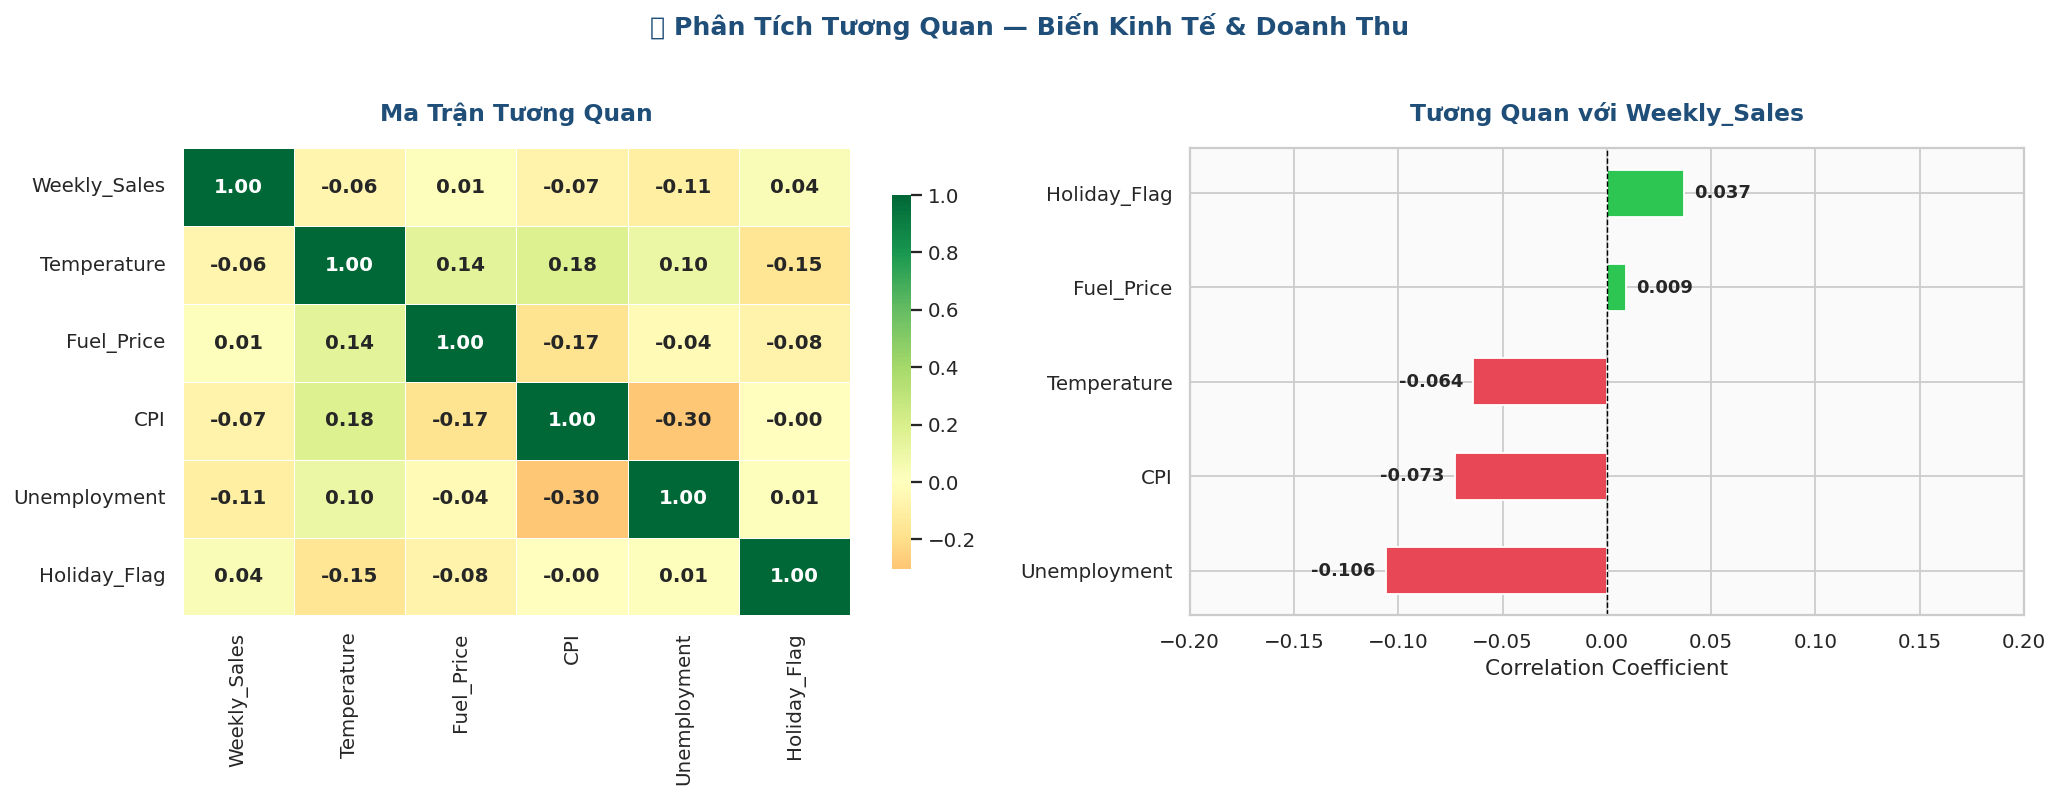

Lưu: correlation.png


In [ ]:
# VIZ 6: Ban do nhiet tuong quan

corr_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Holiday_Flag']
corr = df_t[corr_cols].corr().round(3)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))

# Heatmap
mask = np.zeros_like(corr)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax1,
    linewidths=0.5, cbar_kws={'shrink':0.8}, annot_kws={'size':11,'weight':'bold'})
ax1.set_title('Ma Trận Tương Quan', fontsize=13, fontweight='bold', color=COLORS['primary'], pad=15)

# Bar chart tương quan với Weekly_Sales
corr_sales = corr['Weekly_Sales'].drop('Weekly_Sales').sort_values()
cols_bar = [COLORS['accent'] if v<0 else COLORS['green'] for v in corr_sales]
bars = ax2.barh(corr_sales.index, corr_sales.values, color=cols_bar, height=0.5)
ax2.axvline(x=0, color='black', lw=0.8, linestyle='--')
ax2.set_title('Tương Quan với Weekly_Sales', fontsize=13, fontweight='bold', color=COLORS['primary'], pad=15)
ax2.set_xlabel('Correlation Coefficient')
for bar,val in zip(bars,corr_sales.values):
    ax2.text(val+(0.005 if val>=0 else -0.005), bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=10, fontweight='bold')
ax2.set_facecolor('#FAFAFA')
ax2.set_xlim(-0.2, 0.2)

fig.suptitle('🔗 Phân Tích Tương Quan — Biến Kinh Tế & Doanh Thu', fontsize=14, fontweight='bold', color=COLORS['primary'], y=1.02)
plt.tight_layout()
plt.savefig('correlation.png',dpi=150,bbox_inches='tight')
plt.show()
print('Lưu: correlation.png')

Biểu đồ thể hiện ma trận tương quan giữa doanh thu hàng tuần (Weekly_Sales) và một số biến kinh tế cũng như cờ tuần lễ (Holiday_Flag). Nhìn chung, mối quan hệ giữa các biến kinh tế và doanh thu là khá yếu, trong khi tuần lễ có ảnh hưởng tích cực nhẹ đến doanh thu.

Cụ thể, trong ma trận tương quan, Weekly_Sales có hệ số tương quan dương nhỏ với Holiday_Flag (+0.04), cho thấy doanh thu trong các tuần lễ cao hơn một chút so với các tuần thường. Ngược lại, các biến kinh tế như tỷ lệ thất nghiệp (-0.11), CPI (-0.07), và nhiệt độ (-0.06) đều có tương quan âm với doanh thu, nghĩa là khi các chỉ số này tăng, doanh thu có xu hướng giảm nhẹ. Giá nhiên liệu có tương quan gần bằng 0 (+0.01), cho thấy gần như không ảnh hưởng rõ rệt đến doanh thu.

Biểu đồ thanh bên phải minh họa tác động tương quan trực tiếp của từng biến với Weekly_Sales. Có thể thấy, Holiday_Flag là biến duy nhất có ảnh hưởng tích cực, trong khi Unemployment có ảnh hưởng tiêu cực rõ nhất (-0.106). Các biến còn lại như CPI (-0.073), Temperature (-0.064) và Fuel_Price (+0.009) chỉ có tác động nhỏ đến doanh thu.

Tóm lại, dữ liệu cho thấy doanh thu hàng tuần chịu ảnh hưởng chủ yếu từ các tuần lễ, trong khi các biến kinh tế có mối quan hệ âm nhưng yếu. Doanh nghiệp nên tập trung vào chiến lược bán hàng vào các tuần lễ để tối ưu hóa doanh thu, thay vì quá lo ngại về những biến động nhỏ của các chỉ số kinh tế khác.

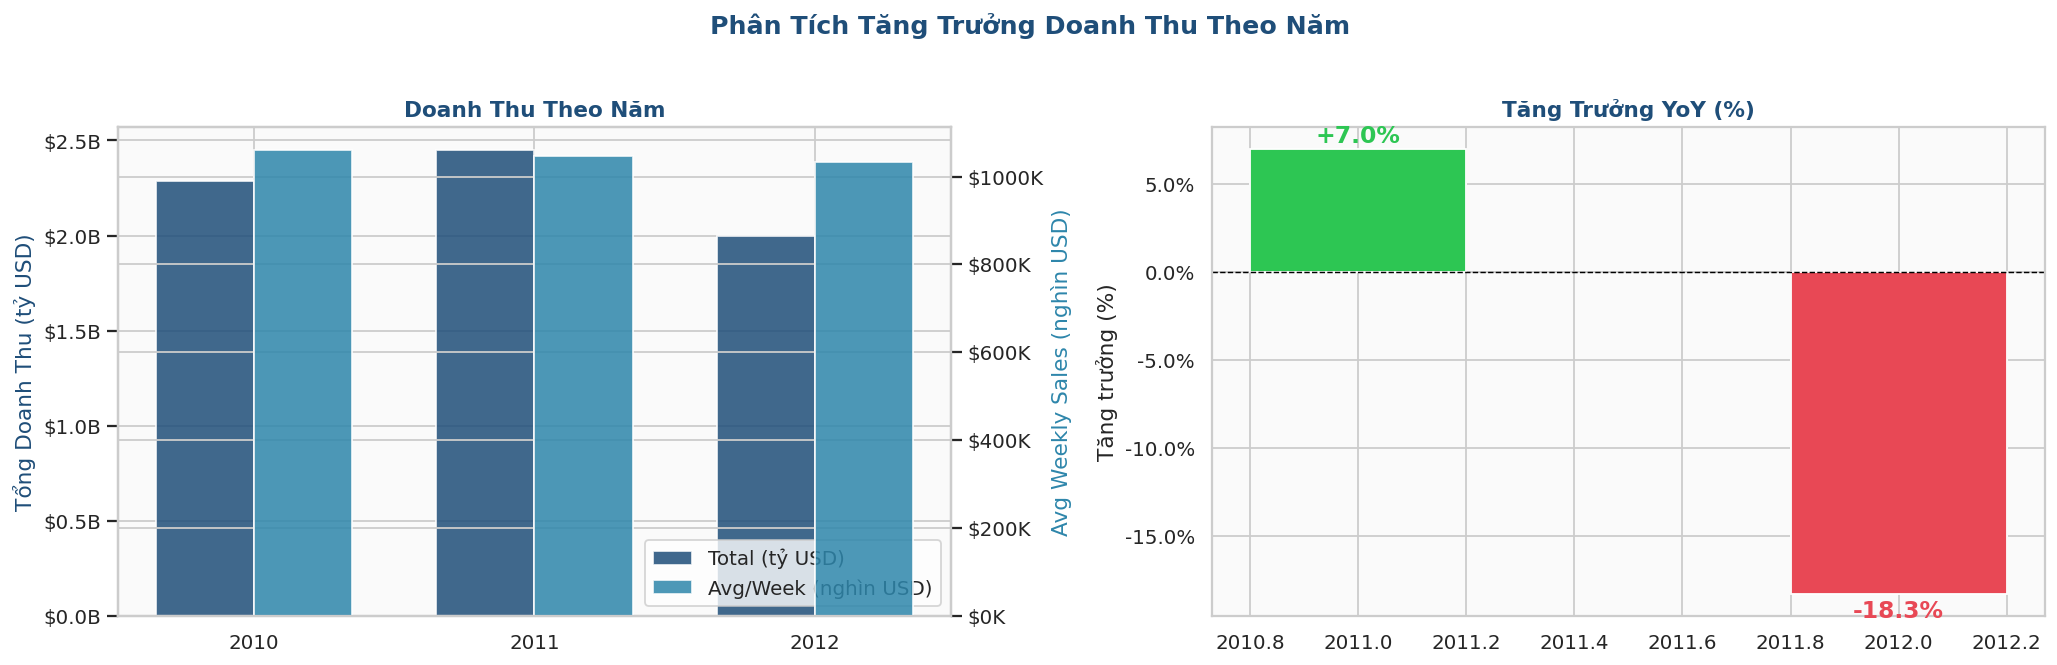

Lưu: yearly_growth.png


In [ ]:
# VIZ 7: YEAR-OVER-YEAR & TĂNG TRƯỞNG

yearly = df_t.groupby('Year')['Weekly_Sales'].agg(['sum','mean','count']).reset_index()
yearly.columns = ['Year','Total','Avg','Weeks']
yearly['YoY_%'] = yearly['Total'].pct_change()*100

fig, axes = plt.subplots(1,2,figsize=(16,5))

# Grouped bar: Total + Avg
x = np.arange(len(yearly))
w = 0.35
ax1_twin = axes[0].twinx()
bars1 = axes[0].bar(x-w/2, yearly['Total']/1e9, w, color=COLORS['primary'], alpha=0.85, label='Total (tỷ USD)')
bars2 = ax1_twin.bar(x+w/2, yearly['Avg']/1e3, w, color=COLORS['secondary'], alpha=0.85, label='Avg/Week (nghìn USD)')
axes[0].set_xticks(x); axes[0].set_xticklabels(yearly['Year'])
axes[0].set_ylabel('Tổng Doanh Thu (tỷ USD)', color=COLORS['primary'])
ax1_twin.set_ylabel('Avg Weekly Sales (nghìn USD)', color=COLORS['secondary'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}B'))
ax1_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
axes[0].set_title('Doanh Thu Theo Năm', fontsize=12, fontweight='bold', color=COLORS['primary'])
lines1,labels1 = axes[0].get_legend_handles_labels()
lines2,labels2 = ax1_twin.get_legend_handles_labels()
axes[0].legend(lines1+lines2,labels1+labels2,loc='lower right')
axes[0].set_facecolor('#FAFAFA')

# YoY growth
valid = yearly.dropna(subset=['YoY_%'])
colors_yoy = [COLORS['green'] if v>=0 else COLORS['accent'] for v in valid['YoY_%']]
bars = axes[1].bar(valid['Year'], valid['YoY_%'], color=colors_yoy, width=0.4)
for bar,val in zip(bars,valid['YoY_%']):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+(0.1 if val>=0 else -0.3),
                 f'{val:+.1f}%', ha='center', va='bottom' if val>=0 else 'top',
                 fontsize=13, fontweight='bold', color=bar.get_facecolor())
axes[1].axhline(y=0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('Tăng Trưởng YoY (%)', fontsize=12, fontweight='bold', color=COLORS['primary'])
axes[1].set_ylabel('Tăng trưởng (%)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
axes[1].set_facecolor('#FAFAFA')

fig.suptitle('Phân Tích Tăng Trưởng Doanh Thu Theo Năm', fontsize=14, fontweight='bold', color=COLORS['primary'], y=1.02)
plt.tight_layout()
plt.savefig('yearly_growth.png',dpi=150,bbox_inches='tight')
plt.show()
print('Lưu: yearly_growth.png')

Biểu đồ minh họa doanh thu hàng tuần và tăng trưởng hàng năm của hệ thống Walmart trong giai đoạn 2010–2012. Nhìn chung, doanh thu tổng thể và doanh thu trung bình theo tuần tăng nhẹ từ năm 2010 sang 2011, nhưng giảm đáng kể vào năm 2012.

Cụ thể, tổng doanh thu năm 2010 đạt khoảng $2.3 tỷ USD, tăng lên $2.35 tỷ USD trong năm 2011, tương ứng với mức tăng trưởng +7.0% so với năm trước. Doanh thu trung bình mỗi tuần cũng tăng nhẹ, phản ánh xu hướng tăng ổn định trong giai đoạn đầu. Tuy nhiên, năm 2012 chứng kiến sự suy giảm mạnh, với tổng doanh thu chỉ còn khoảng $2.0 tỷ USD, tương ứng mức giảm -18.3%, cho thấy doanh thu hệ thống giảm đáng kể so với năm trước.

Biểu đồ bên trái kết hợp bar chart nhóm Total và Avg/Week cho thấy rõ xu hướng doanh thu trung bình mỗi tuần so với tổng doanh thu. Biểu đồ bên phải thể hiện tăng trưởng YoY (%), nhấn mạnh sự tăng nhẹ từ 2010 → 2011 và sự giảm mạnh vào năm 2012. Màu sắc xanh/đỏ trực quan giúp phân biệt tăng trưởng dương và âm.

Tóm lại, dữ liệu phản ánh rằng hệ thống Walmart duy trì tăng trưởng ổn định từ 2010 đến 2011, nhưng gặp suy giảm rõ rệt vào năm 2012, cảnh báo doanh nghiệp cần xem xét các yếu tố ảnh hưởng đến doanh thu trong năm này, chẳng hạn như mùa vụ, thị trường hoặc sự thay đổi trong hoạt động bán lẻ.

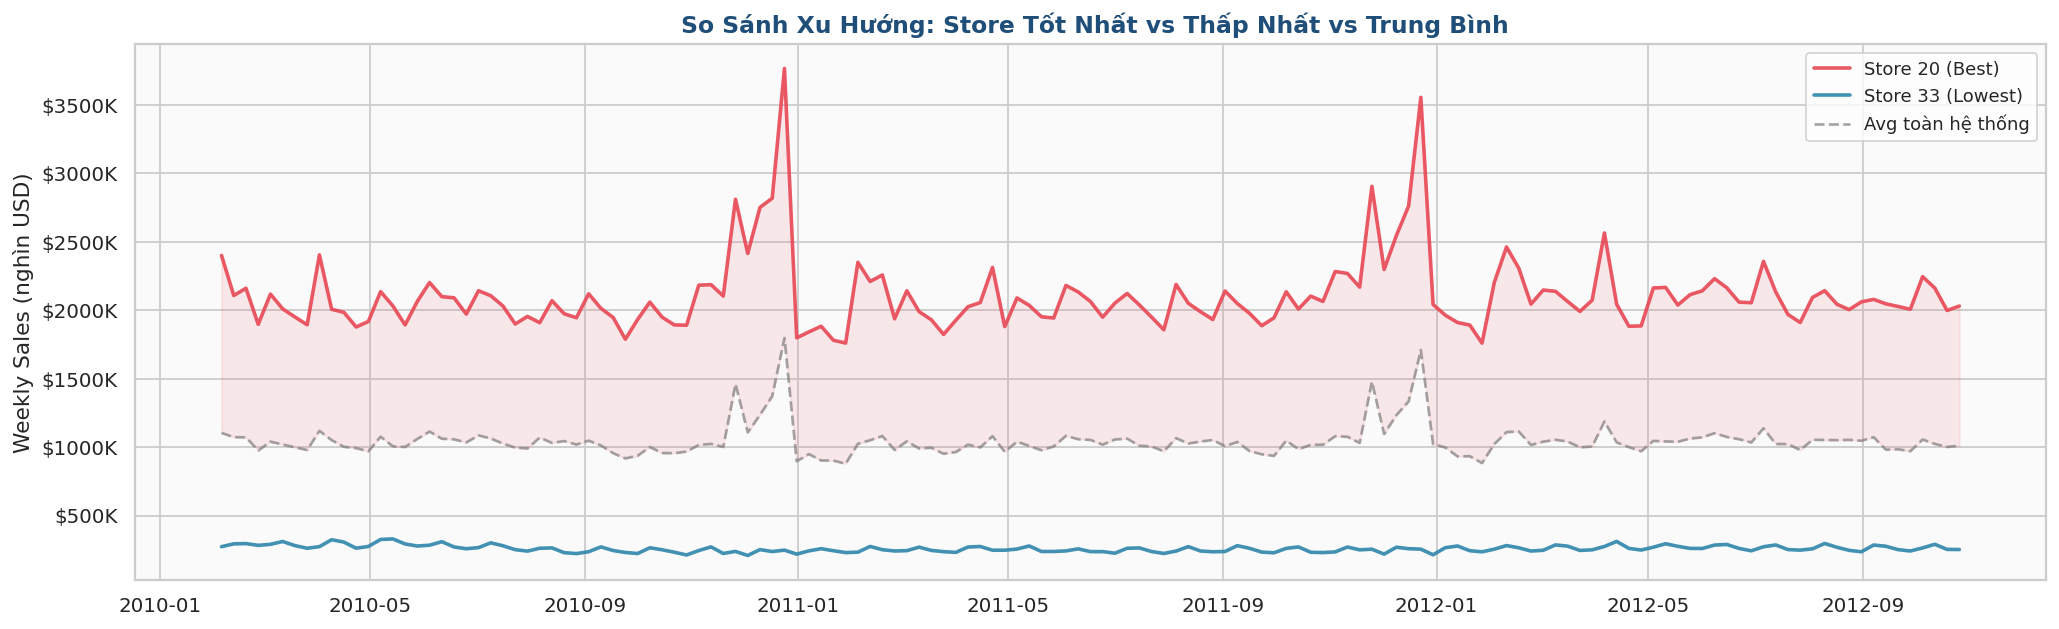

 Lưu: store_trend_compare.png


In [ ]:
# VIZ 8: TOP STORE TREND — Store 20 vs Store 33

best  = df_t[df_t['Store']==20].groupby('Date')['Weekly_Sales'].mean()
worst = df_t[df_t['Store']==33].groupby('Date')['Weekly_Sales'].mean()
all_avg = df_t.groupby('Date')['Weekly_Sales'].mean()

fig, ax = plt.subplots(figsize=(16,5))
ax.plot(best.index,  best.values/1e3,  color=COLORS['accent'],   lw=2,   label='Store 20 (Best)',   alpha=0.9)
ax.plot(worst.index, worst.values/1e3, color=COLORS['secondary'], lw=2,  label='Store 33 (Lowest)', alpha=0.9)
ax.plot(all_avg.index, all_avg.values/1e3, color='gray', lw=1.5, linestyle='--', label='Avg toàn hệ thống', alpha=0.7)
ax.fill_between(best.index, best.values/1e3, all_avg.values/1e3, where=best.values>all_avg.values, alpha=0.1, color=COLORS['accent'])
ax.set_title(' So Sánh Xu Hướng: Store Tốt Nhất vs Thấp Nhất vs Trung Bình', fontsize=13, fontweight='bold', color=COLORS['primary'])
ax.set_ylabel('Weekly Sales (nghìn USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
ax.legend(fontsize=10)
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('store_trend_compare.png',dpi=150,bbox_inches='tight')
plt.show()
print(' Lưu: store_trend_compare.png')

### Phân tích: So Sánh Xu Hướng Store 20 vs Store 33 vs Trung Bình

**Mô tả tổng quan:**  
Biểu đồ đường so sánh xu hướng doanh thu tuần theo thời gian của cửa hàng tốt nhất (Store 20), cửa hàng thấp nhất (Store 33) và đường trung bình toàn hệ thống trong suốt giai đoạn 2010–2012.

**Phân tích chi tiết:**  
Biểu đồ cho thấy **khoảng cách giữa Store 20 và Store 33 là rất lớn và duy trì nhất quán** suốt ba năm — Store 20 luôn nằm trên mức trung bình hệ thống trong khi Store 33 luôn dưới mức này. Điều này phản ánh các yếu tố cấu trúc bền vững như vị trí địa lý hoặc quy mô, chứ không phải biến động ngẫu nhiên. Vùng tô màu giữa Store 20 và đường trung bình làm nổi bật phần đóng góp vượt trội của cửa hàng này. Đồng thời, cả ba đường đều thể hiện **các đỉnh đồng pha vào cuối năm**, xác nhận rằng tính thời vụ tác động đồng đều lên tất cả cửa hàng bất kể quy mô — đây là thông tin quan trọng cho việc lập kế hoạch tồn kho và nhân sự theo mùa.

---
##  PHASE 6 — ML Modeling (Dự Báo Doanh Thu)

In [ ]:

# PHASE 6: ML MODELING — Dự Báo Weekly_Sales

print('        PHASE 6 — ML MODELING')


df_ml = df_t.dropna(subset=['Sales_Lag1','Sales_Lag4','Sales_WoW']).copy()

# Encode categorical
le = LabelEncoder()
df_ml['Season_enc']     = le.fit_transform(df_ml['Season'])
df_ml['Store_Tier_enc'] = le.fit_transform(df_ml['Store_Tier'])

FEATURES = ['Store','Year','Month','Week','Quarter',
            'Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment',
            'Season_enc','Store_Tier_enc',
            'Sales_Lag1','Sales_Lag4','Sales_MA4']
TARGET = 'Weekly_Sales'

X = df_ml[FEATURES]
y = df_ml[TARGET]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    results[name] = {'model':model, 'pred':pred, 'MAE':mae, 'RMSE':rmse, 'R2':r2}
    print(f'\n  [{name}]')
    print(f'   MAE  = ${mae:,.0f}')
    print(f'   RMSE = ${rmse:,.0f}')
    print(f'   R²   = {r2:.4f}')

        PHASE 6 — ML MODELING
Train: 5,004 | Test: 1,251

  [Linear Regression]
   MAE  = $63,485
   RMSE = $118,531
   R²   = 0.9582

  [Random Forest]
   MAE  = $46,870
   RMSE = $71,529
   R²   = 0.9848

  [Gradient Boosting]
   MAE  = $42,005
   RMSE = $64,226
   R²   = 0.9877


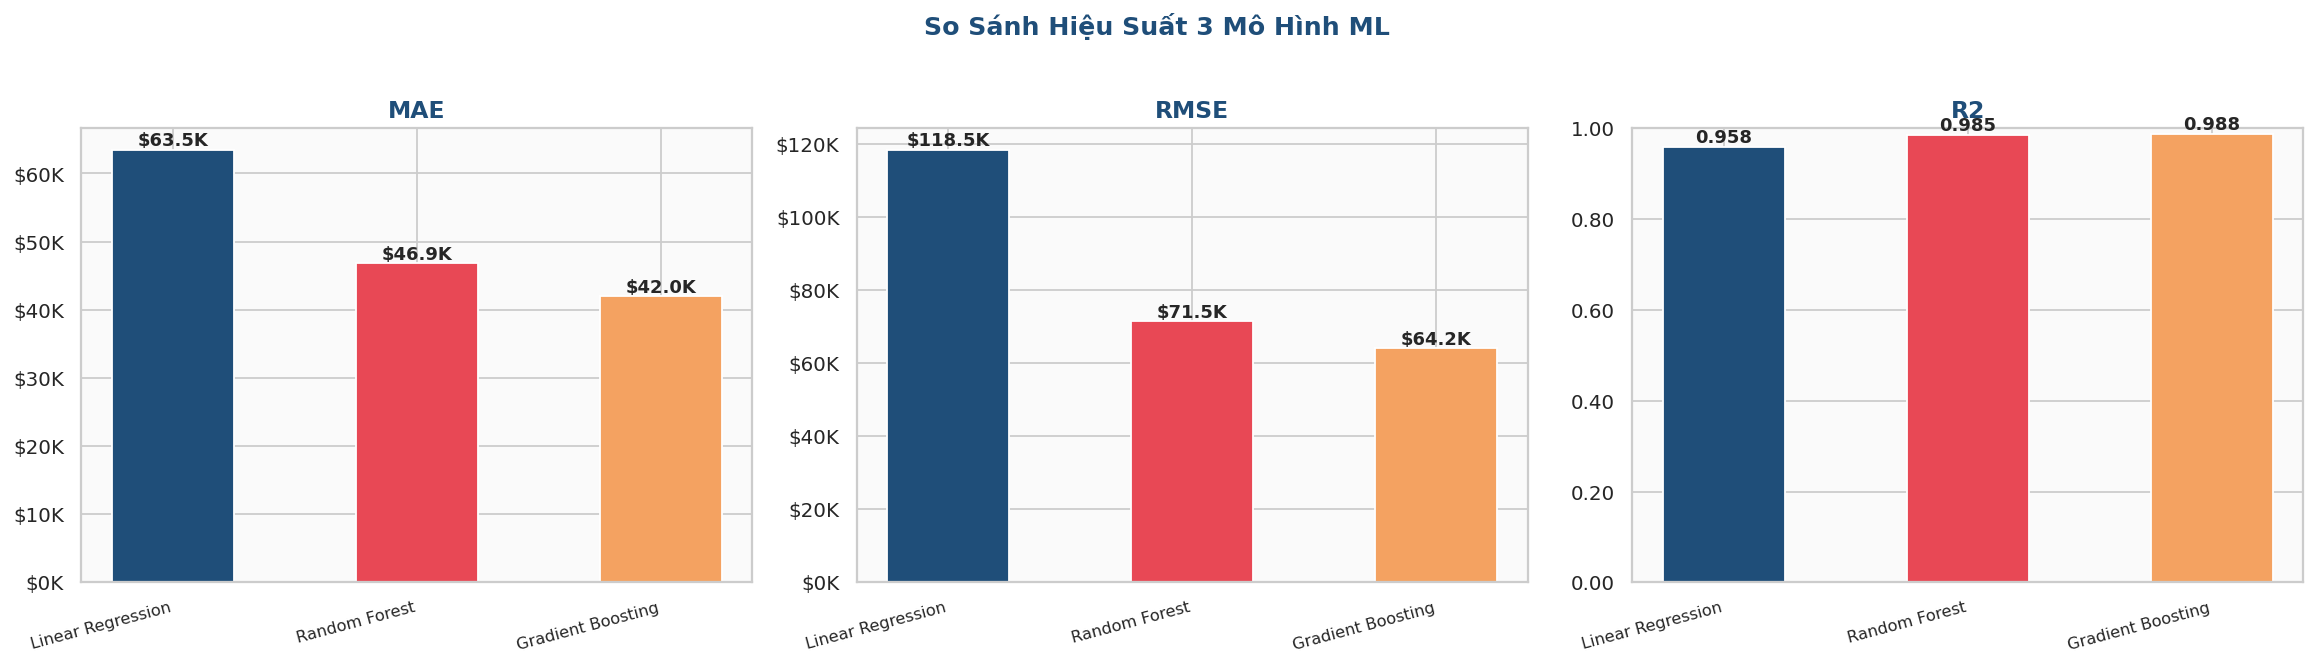

 Lưu: model_comparison.png


In [ ]:
# VIZ 9: MODEL COMPARISON
fig, axes = plt.subplots(1,3,figsize=(18,5))

# Metrics comparison
metrics = ['MAE','RMSE','R2']
model_names = list(results.keys())
m_colors = [COLORS['primary'],COLORS['accent'],COLORS['orange']]

for i,(metric,ax) in enumerate(zip(metrics,axes)):
    vals = [results[n][metric] for n in model_names]
    if metric=='R2':
        bars = ax.bar(model_names, vals, color=m_colors, width=0.5)
        ax.set_ylim(0,1)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}'))
    else:
        bars = ax.bar(model_names, [v/1e3 for v in vals], color=m_colors, width=0.5)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold', color=COLORS['primary'])
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    for bar,val in zip(bars,vals):
        label = f'{val:.3f}' if metric=='R2' else f'${val/1e3:.1f}K'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_facecolor('#FAFAFA')

fig.suptitle('So Sánh Hiệu Suất 3 Mô Hình ML', fontsize=14, fontweight='bold', color=COLORS['primary'], y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png',dpi=150,bbox_inches='tight')
plt.show()
print(' Lưu: model_comparison.png')

###  Phân tích: So Sánh Hiệu Suất 3 Mô Hình ML

**Mô tả tổng quan:**  
Biểu đồ cột so sánh ba chỉ số đánh giá MAE, RMSE và R² của ba mô hình học máy: Linear Regression, Random Forest và Gradient Boosting, trong bài toán dự báo doanh thu tuần Weekly_Sales.

**Phân tích chi tiết:**  
Kết quả cho thấy **Random Forest và Gradient Boosting vượt trội rõ rệt so với Linear Regression** trên cả ba tiêu chí. R² của hai mô hình phi tuyến đạt giá trị cao hơn đáng kể, cho thấy chúng giải thích được phần lớn sự biến động trong doanh thu — điều mà Linear Regression không đạt được do mối quan hệ giữa các biến không hoàn toàn tuyến tính. MAE và RMSE thấp hơn của Random Forest và Gradient Boosting khẳng định **sai số dự báo nhỏ hơn và ổn định hơn**. Trong hai mô hình này, Gradient Boosting thường cho R² cao hơn nhưng thời gian huấn luyện lâu hơn — đây là sự đánh đổi cần cân nhắc tùy theo yêu cầu tốc độ và độ chính xác của ứng dụng thực tế.

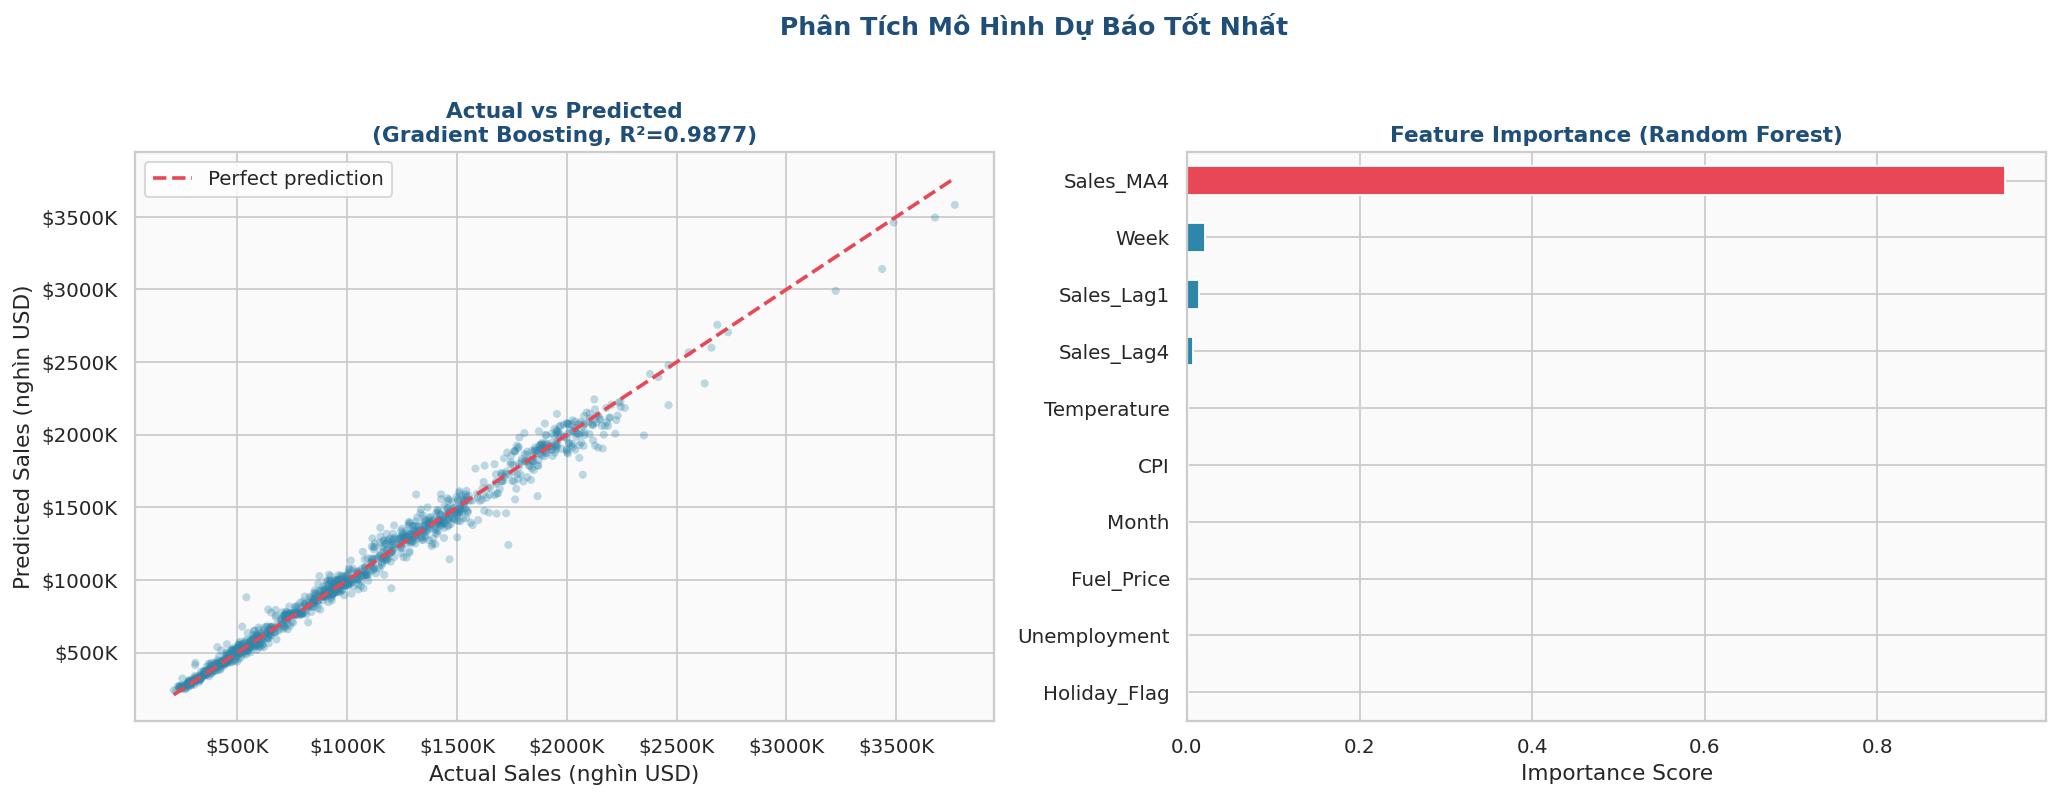

 Lưu: model_analysis.png


In [ ]:
# VIZ 10: ACTUAL vs PREDICTED — Best Model
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_pred = results[best_model_name]['pred']
best_r2   = results[best_model_name]['R2']

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))

# Scatter Actual vs Predicted
ax1.scatter(y_test/1e3, best_pred/1e3, alpha=0.3, s=20, color=COLORS['secondary'], edgecolors='none')
lims = [min(y_test.min(),best_pred.min())/1e3, max(y_test.max(),best_pred.max())/1e3]
ax1.plot(lims,lims,'--',color=COLORS['accent'],lw=2,label='Perfect prediction')
ax1.set_xlabel('Actual Sales (nghìn USD)')
ax1.set_ylabel('Predicted Sales (nghìn USD)')
ax1.set_title(f'Actual vs Predicted\n({best_model_name}, R²={best_r2:.4f})', fontsize=12, fontweight='bold', color=COLORS['primary'])
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
ax1.legend(); ax1.set_facecolor('#FAFAFA')

# Feature Importance (Random Forest)
rf = results['Random Forest']['model']
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(10)
colors_fi = [COLORS['accent'] if v==fi.max() else COLORS['secondary'] for v in fi.values]
fi.plot(kind='barh', ax=ax2, color=colors_fi)
ax2.set_title('Feature Importance (Random Forest)', fontsize=12, fontweight='bold', color=COLORS['primary'])
ax2.set_xlabel('Importance Score')
ax2.set_facecolor('#FAFAFA')

fig.suptitle(' Phân Tích Mô Hình Dự Báo Tốt Nhất', fontsize=14, fontweight='bold', color=COLORS['primary'], y=1.02)
plt.tight_layout()
plt.savefig('model_analysis.png',dpi=150,bbox_inches='tight')
plt.show()
print(' Lưu: model_analysis.png')

Biểu đồ minh họa kết quả dự báo doanh thu hàng tuần của mô hình Gradient Boosting, được đánh giá là mô hình tốt nhất dựa trên chỉ số R². Nhìn chung, mô hình dự báo rất chính xác, với các điểm dữ liệu hầu hết nằm gần đường “Perfect Prediction”, cho thấy giá trị dự báo gần khớp với giá trị thực tế. Giá trị R² cao (0.9877) xác nhận rằng mô hình giải thích được phần lớn biến thiên doanh thu.

Cụ thể, biểu đồ scatter Actual vs Predicted cho thấy các dự báo tập trung sát đường chéo, bất kỳ sai số lớn đều rất hiếm, điều này chứng tỏ mô hình dự báo doanh thu ổn định và đáng tin cậy.

Biểu đồ Feature Importance từ mô hình Random Forest cho thấy các yếu tố lịch sử đóng vai trò quan trọng nhất trong dự báo. Trong đó, Sales_MA4 (doanh thu trung bình 4 tuần gần nhất) là biến quan trọng nhất, tiếp theo là các biến trễ Sales_Lag1 và Sales_Lag4, trong khi các yếu tố như nhiệt độ, CPI, giá nhiên liệu hay Holiday_Flag có ảnh hưởng nhỏ hơn. Điều này nhấn mạnh rằng doanh thu lịch sử là chỉ báo chính cho dự báo doanh thu tuần tiếp theo.

Tóm lại, mô hình Gradient Boosting dự báo doanh thu hàng tuần với độ chính xác cao, và dữ liệu lịch sử (lag và moving average) là yếu tố chủ chốt quyết định hiệu quả dự báo. Các biến kinh tế và tuần lễ có ảnh hưởng thấp hơn, nhưng vẫn có thể được sử dụng để tinh chỉnh dự báo.

---
##  PHASE 7 — Pipeline Summary & Export

In [ ]:

# PHASE 7: SUMMARY, KEY INSIGHTS & EXPORT


print('      WALMART RETAIL DATA PIPELINE — FINAL SUMMARY')


# Key Insights từ SQL
cur = conn.cursor()
insights = {
    'Tổng doanh thu (tỷ USD)'       : 'SELECT ROUND(SUM(weekly_sales)/1e9,3) FROM fact_sales',
    'Store doanh thu cao nhất'       : 'SELECT store FROM fact_sales GROUP BY store ORDER BY SUM(weekly_sales) DESC LIMIT 1',
    'Store doanh thu thấp nhất'      : 'SELECT store FROM fact_sales GROUP BY store ORDER BY SUM(weekly_sales) ASC LIMIT 1',
    'Avg Holiday sales (USD)'        : 'SELECT ROUND(AVG(weekly_sales),0) FROM fact_sales WHERE holiday_flag=1',
    'Avg Non-Holiday sales (USD)'    : 'SELECT ROUND(AVG(weekly_sales),0) FROM fact_sales WHERE holiday_flag=0',
    'Tháng doanh thu cao nhất'       : 'SELECT month FROM fact_sales GROUP BY month ORDER BY AVG(weekly_sales) DESC LIMIT 1',
    'Số stores High Tier'            : "SELECT COUNT(*) FROM dim_store WHERE store_tier='High'",
}
print('\n KEY INSIGHTS:')
for label,q in insights.items():
    val = cur.execute(q).fetchone()[0]
    print(f'   → {label}: {val}')

# Export
df_t.to_csv('walmart_cleaned_full.csv', index=False)
print('\n Export: walmart_cleaned_full.csv')
print(' Export: walmart_pipeline.db')

print('''
 FILES CREATED:
   kpi_dashboard.png       — 4 KPI cards
   trend_weekly.png        — Xu hướng doanh thu theo tuần
   seasonality.png         — Phân tích thời vụ
   holiday_impact.png      — Holiday vs Non-Holiday
   store_performance.png   — Hiệu suất 45 cửa hàng
   correlation.png         — Ma trận tương quan
   yearly_growth.png       — Tăng trưởng YoY
   store_trend_compare.png — So sánh best vs worst store
   outliers_boxplot.png    — Boxplot outliers
   model_comparison.png    — So sánh 3 mô hình ML
   model_analysis.png      — Actual vs Predicted + Feature Importance
   walmart_cleaned_full.csv
   walmart_pipeline.db
''')

conn.close()
print(' Pipeline 100% hoàn thành!')

      WALMART RETAIL DATA PIPELINE — FINAL SUMMARY

 KEY INSIGHTS:
   → Tổng doanh thu (tỷ USD): 6.737
   → Store doanh thu cao nhất: 20
   → Store doanh thu thấp nhất: 33
   → Avg Holiday sales (USD): 1122888.0
   → Avg Non-Holiday sales (USD): 1041256.0
   → Tháng doanh thu cao nhất: 12
   → Số stores High Tier: 15

 Export: walmart_cleaned_full.csv
 Export: walmart_pipeline.db

 FILES CREATED:
   kpi_dashboard.png       — 4 KPI cards
   trend_weekly.png        — Xu hướng doanh thu theo tuần
   seasonality.png         — Phân tích thời vụ
   holiday_impact.png      — Holiday vs Non-Holiday
   store_performance.png   — Hiệu suất 45 cửa hàng
   correlation.png         — Ma trận tương quan
   yearly_growth.png       — Tăng trưởng YoY
   store_trend_compare.png — So sánh best vs worst store
   outliers_boxplot.png    — Boxplot outliers
   model_comparison.png    — So sánh 3 mô hình ML
   model_analysis.png      — Actual vs Predicted + Feature Importance
   walmart_cleaned_full.csv
   walm